# SENDAs Agreement 1 Update 2010-2022 (Prediction, step 2.2, shap-informed models)

This notebook was converted automatically from `prediction22.qmd`.

Quarto-specific YAML/options were preserved in the first raw cell. I also inserted setup cells at the beginning for project-root detection, loading `pred21_ndp_2026_03_26.Rdata`, plot sizing, and optional `renv` repair.


In [27]:
# --- Setup: project root, data load, plot size/resolution, and renv activation ---

# adjust plot size and resolution for high-quality output

# --- Load pred21_ndp_2026_03_26.Rdata (simple, project-root aware, no functions) --- 
# 1) Locate the file anywhere under the project root (current WD with a trailing "/cons" trimmed)
project_root <- sub("(/)?cons/?$", "", normalizePath(getwd(), winslash = "/", mustWork = FALSE))
fname        <- "pred21_ndp_2026_03_26.Rdata"
hits <- list.files(project_root, pattern = paste0("^", fname, "$"),
                   recursive = TRUE, full.names = TRUE, ignore.case = TRUE)

# If not found and path contains "Documents\GitHub\", try the data folder
if (!length(hits) && grepl("Documents[/\\\\]GitHub", project_root)) {
  alt_data_dir <- file.path(Sys.getenv("USERPROFILE"), "Documents/GitHub/data")
  message("File not found in project root. Trying alternative data directory: ", alt_data_dir)
  hits <- list.files(alt_data_dir, pattern = paste0("^", fname, "$"),
                     recursive = TRUE, full.names = TRUE, ignore.case = TRUE)
}

if (!length(hits)) {
  stop("File not found: ", fname, 
       "\nSearched under: ", project_root,
       "\nAnd under: ", file.path(Sys.getenv("USERPROFILE"), "Documents/GitHub/data"))
}
path <- hits[1]  # take first match
message("Loading: ", path)

# 2) Load into a dedicated environment (keeps .GlobalEnv clean)
env_pred <- new.env(parent = emptyenv())
loaded_objects <- load(path, envir = env_pred)
message("Loaded ", length(loaded_objects), " object(s): ", paste(loaded_objects, collapse = ", "))

# 3) Quick sanity check for each loaded object
for (obj_name in loaded_objects) {
  obj <- get(obj_name, envir = env_pred)
  message("\n--- ", obj_name, " ---")
  if (is.data.frame(obj)) {
    message("Rows: ", nrow(obj), " | Cols: ", ncol(obj))
  } else {
    message("Class: ", paste(class(obj), collapse = ", "), " | Length/Size: ", length(obj))
  }
  # print(str(obj))
}

# 4) Extract all loaded objects to global environment
for (obj_name in loaded_objects) {
  assign(obj_name, get(obj_name, envir = env_pred), envir = .GlobalEnv)
}

# Clean up temporary environment
rm(env_pred)

options(jupyter.max_output_size = Inf)
options(repr.plot.width = 16 * 1.5, repr.plot.height = 12 * 1.5)
options(repr.plot.res = 300)

# --- renv activation with fallback ---
Sys.setenv(RENV_PROJECT = project_root)

# Try project_root renv first, then fallback to Documents/GitHub/renv
renv_activate <- file.path(project_root, "renv/activate.R")
if (!file.exists(renv_activate)) {
  # Fallback: construct path from USERPROFILE environment variable
  fallback_root <- file.path(Sys.getenv("USERPROFILE"), "Documents/GitHub")
  renv_activate <- file.path(fallback_root, "renv/activate.R")
  
  if (file.exists(renv_activate)) {
    message("Project renv not found. Using fallback renv at: ", renv_activate)
    Sys.setenv(RENV_PROJECT = fallback_root)
  } else {
    stop("renv/activate.R not found at project root nor at fallback location: ", file.path(Sys.getenv("USERPROFILE"), "Documents/GitHub/renv/activate.R"))
  }
}

source(renv_activate)

getwd()
Sys.getenv("RENV_PROJECT")
.libPaths()

Loading: C:/Users/nDP/Documents/GitHub/data/20241015_out/pred21_ndp_2026_03_26.Rdata
Loaded 281 object(s): infectious_set, find_latest_file, cal_readmit2, mode_pick_int, cal_readmit3, python_columns, nm, cal_death_full_ici, collapse_first_sub_used_other, .cph_boot_extract_ibs, char_variables, secret_file_path, cols_to_exclude, total_cpus, decrypt_column, n1b_cases, api_key, plot_cloglog_comb, encrypt_column, renviron_path, .mi_cv_build_level_mapping, subkey_to_label, hits, missing_pct, target_cols, py_split, aicc_death_upd2, dummy_formula, apply_ordered_mappings, t_grid, cif_d_before, m4_cases, calibrate_cph_grouped, m3_runs, violations, ph_test_death, root, ci_first, cal_readmit, existing_lines, obj, .Random.seed, n_before, results_readmit2_ibs, formula_readmit_updated2, decrypt_chr, DUMMY_REFERENCE, .mi_cv_normalize_call_name, pairs, key_exists, encrypt_chr, sum_dates_polars, normalize_txt, find_python_rel, .mi_cv_collect_strata_term_labels, time_before_dedup2, numerical_vars2, lab_f

[1] "C:/Users/nDP/Documents/GitHub/renv/library/windows/R-4.4/x86_64-w64-mingw32"                
[2] "C:/Users/nDP/AppData/Local/R/cache/R/renv/sandbox/windows/R-4.4/x86_64-w64-mingw32/e0da0d43"

In [28]:
# Function to handle renv environment loading based on working directory rules
load_custom_renv <- function() {
  # Get current working directory
  wd <- getwd()
  
  # Normalize to lowercase for case-insensitive matching
  wd_lower <- tolower(wd)
  
  # Rule 1: If path contains "mi unidad" or "my drive"
  if (grepl("mi unidad", wd_lower) || grepl("my drive", wd_lower)) {
    message("Rule 1: Path is inside Google Drive. Keeping current environment.")
    
  # Rule 2: If path contains "cons"
  } else if (grepl("cons", wd_lower)) {
    parent_dir <- dirname(wd)
    lockfile <- file.path(parent_dir, "renv.lock")
    
    # Rule 3: Check if renv.lock exists in parent directory
    if (file.exists(lockfile)) {
      message("Rule 3: Found renv.lock in parent directory. Restoring environment...")
      renv::restore(lockfile = lockfile, exclude= "polars")
    } else {
      message("Rule 3: No renv.lock found in parent directory. No restore performed.")
    }
    
  # Default case: Path does not match any rule
  } else {
    message("Default: Path does not match rules. Keeping current environment.")
  }
}

# Example usage:
load_custom_renv()


Rule 3: Found renv.lock in parent directory. Restoring environment...
- The library is already synchronized with the lockfile.


In [29]:
# --- Optional renv cleanup / repair ---
# Run this only if you actually need to repair the project library.

unlink("renv/staging", recursive = TRUE, force = TRUE)
unlink("renv/library/windows/R-4.4/x86_64-w64-mingw32/geepack", recursive = TRUE, force = TRUE)
unlink("renv/library/windows/R-4.4/x86_64-w64-mingw32/V8", recursive = TRUE, force = TRUE)

renv::status()
#renv::restore(exclude = c("polars"))

The following package(s) are used in this project, but are not installed:
- geepack

See `?renv::status` for advice on resolving these issues.


<style>
.scrollable-content {
  max-height: 350px;
  overflow-y: auto;
}
pre.scrollable-code {
  max-height: 350px;
  overflow-y: auto;
}
.superbigimage {
  overflow-x: scroll;
  white-space: nowrap;
}
.superbigimage img, 
.superbigimage svg {
  max-width: none;
  height: auto;
}
</style>
<br>

# Data Loading and Exploration

## Loading Packages and uniting databases

<div class="scrollable-content">


In [30]:
#| label: setup
#| results: "hold"
#renv falls back to copying rather than symlinking, which is evidently very slow in this configuration.
renv::settings$use.cache(FALSE)
#only use explicit dependencies (in DESCRIPTION)
renv::settings$snapshot.type("implicit")
#check if rstools is installed
if(Sys.info()["sysname"]=="Windows"){
try(installr::install.Rtools(check_r_update=F))
}
check_quarto_version <- function(required = "1.7.29", comparator = c("ge","gt","le","lt","eq")) {
  comparator <- match.arg(comparator)
  current <- package_version(paste(unlist(quarto::quarto_version()), collapse = "."))
  req     <- package_version(required)
  ok <- switch(comparator,
               ge = current >= req,
               gt = current >  req,
               le = current <= req,
               lt = current <  req,
               eq = current == req)
  if (!ok) {
    stop(sprintf("Quarto version check failed: need %s %s (installed: %s).",
                 comparator, required, current), call. = FALSE)
  }
  invisible(TRUE)
}
check_quarto_version("1.7.29", "ge") 
#change repository to CL
local({
  r <- getOption("repos")
  r["CRAN"] <- "https://cran.dcc.uchile.cl/"
  options(repos=r)
})
if(!require(pacman)){install.packages("pacman");require(pacman)}
if(!require(pak)){install.packages("pak");require(pak)}
pacman::p_unlock(lib.loc = .libPaths()) #para no tener problemas reinstalando paquetes
if(Sys.info()["sysname"]=="Windows"){
if (getRversion() != "4.4.1") { stop("Requires R version 4.4.1; Actual: ", getRversion()) }
}
#check docker
check_docker_running <- function() {
  # Try running 'docker info' to check if Docker is running
  system("docker info", intern = TRUE, ignore.stderr = TRUE)
}
if(Sys.info()["sysname"]=="Windows"){
  install_docker <- function() {
    # Open the Docker Desktop download page in the browser for installation
    browseURL("https://www.docker.com/products/docker-desktop")
  }
  # Main logic
  if (inherits(try(check_docker_running(), silent = TRUE), "try-error")) {
    liftr::install_docker()
  } else {
    message("Docker is running.")
  }
}
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#PACKAGES#######################################################################
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
unlink("*_cache", recursive=T)
pak::pak_sitrep()
# pak::sysreqs_check_installed(unique(unlist(paks)))
#pak::lockfile_create(unique(unlist(paks)),  "dependencies_duplicates24.lock", dependencies=T)
#pak::lockfile_install("dependencies_duplicates24.lock")
#https://rdrr.io/cran/pak/man/faq.html
#pak::cache_delete()
library(tidytable)
library(ggplot2)
library(readr)
library(tableone)
library(survivalmodels)
#renv::install("patchwork@1.2.0")
library(rms)
library(survidm)
library(caret)
library(survival)
library(caret)
library(dplyr)
library(survex)
library(pec)
library(future)
library(future.apply)
library(parallel)
library(mice)
library(riskRegression)
library(tidyr)
library(doFuture)
library(vcd)
library(survAUC)

#flexsurv
#if(!require(compareCstat)){install.pacakges("compareCstat")}
# library(shapr)#https://norskregnesentral.github.io/shapr/
# library(SemiMarkov)#https://www.degruyterbrill.com/document/doi/10.1515/ijb-2020-0083/html?lang=en
# #https://www.jclinepi.com/article/S0895-4356(24)00142-2/fulltext
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
# 3. Activate polars code completion (safe to try even if it fails)
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
#try(polars_code_completion_activate())
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
# 4. BPMN from GitHub (not on CRAN, so install via devtools if missing)
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
if (!requireNamespace("bpmn", quietly = TRUE)) {
  devtools::install_github("bergant/bpmn")
}
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
# 5. PhantomJS Check (use webshot if PhantomJS is missing)
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
# if (!webshot::is_phantomjs_installed()) {
#   webshot::install_phantomjs()
# }
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#FUNCTIONS######################################################################
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
# NO MORE DEBUGS
options(error = NULL)        # si antes tenías options(error = recover) o browser)
options(browserNLdisabled = FALSE)
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
#NAs are replaced with "" in knitr kable
options(knitr.kable.NA = '')
pander::panderOptions('big.mark', ',')
pander::panderOptions('decimal.mark', '.')
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
#to format rows in bold
format_cells <- function(df, rows ,cols, value = c("italics", "bold", "strikethrough")){
  # select the correct markup
  # one * for italics, two ** for bold
  map <- setNames(c("*", "**", "~~"), c("italics", "bold", "strikethrough"))
  markup <- map[value]  
  for (r in rows){
    for(c in cols){
      # Make sure values are not factors
      df[[c]] <- as.character( df[[c]])
      # Update formatting
      df[r, c] <- ifelse(nchar(df[r, c])==0,"",paste0(markup, gsub(" ", "", df[r, c]), markup))
    }
  }
  return(df)
}
#To produce line breaks in messages and warnings
knitr::knit_hooks$set(
   error = function(x, options) {
     paste('\n\n<div class="alert alert-danger" style="font-size: small !important;">',
           gsub('##', '\n', gsub('^##\ Error', '**Error**', x)),
           '</div>', sep = '\n')
   },
   warning = function(x, options) {
     paste('\n\n<div class="alert alert-warning" style="font-size: small !important;">',
           gsub('##', '\n', gsub('^##\ Warning:', '**Warning**', x)),
           '</div>', sep = '\n')
   },
   message = function(x, options) {
     paste('<div class="message" style="font-size: small !important;">',
           gsub('##', '\n', x),
           '</div>', sep = '\n')
   }
)
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
sum_dates <- function(x){
  cbind.data.frame(
    min= as.Date(min(unclass(as.Date(x)), na.rm=T), origin = "1970-01-01"),
    p001= as.Date(quantile(unclass(as.Date(x)), .001, na.rm=T), origin = "1970-01-01"),
    p005= as.Date(quantile(unclass(as.Date(x)), .005, na.rm=T), origin = "1970-01-01"),
    p025= as.Date(quantile(unclass(as.Date(x)), .025, na.rm=T), origin = "1970-01-01"),
    p25= as.Date(quantile(unclass(as.Date(x)), .25, na.rm=T), origin = "1970-01-01"),
    p50= as.Date(quantile(unclass(as.Date(x)), .5, na.rm=T), origin = "1970-01-01"),
    p75= as.Date(quantile(unclass(as.Date(x)), .75, na.rm=T), origin = "1970-01-01"),
    p975= as.Date(quantile(unclass(as.Date(x)), .975, na.rm=T), origin = "1970-01-01"),
    p995= as.Date(quantile(unclass(as.Date(x)), .995, na.rm=T), origin = "1970-01-01"),
    p999= as.Date(quantile(unclass(as.Date(x)), .999, na.rm=T), origin = "1970-01-01"),
    max= as.Date(max(unclass(as.Date(x)), na.rm=T), origin = "1970-01-01")
  )
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
# Define the function adapted for Polars
sum_dates_polars <- function(df, date_col) {
  # Create the list of quantiles
  quantiles <- c(0.001, 0.005, 0.025, 0.25, 0.5, 0.75, 0.975, 0.995, 0.999)
  # Create expressions to calculate min and max
  expr_list <- list(
    pl$col(date_col)$min()$alias("min"),
    pl$col(date_col)$max()$alias("max")
  )
  # Add expressions for quantiles
  for (q in quantiles) {
    expr_list <- append(expr_list, pl$col(date_col)$quantile(q)$alias(paste0("p", sub("\\.", "", as.character(q)))))
  }
  # Apply the expressions and return a DataFrame with the results
  df$select(expr_list)
}
# Custom function for sampling with a seed
sample_n_with_seed <- function(data, size, seed) {
  set.seed(seed)
  dplyr::sample_n(data, size)
}
# Function to get the most frequent value 
most_frequent <- function(x) { 
  uniq_vals <- unique(x)
  freq_vals <- sapply(uniq_vals, function(val) sum(x == val))
  most_freq <- uniq_vals[which(freq_vals == max(freq_vals))]
  
  if (length(most_freq) == 1) {
    return(most_freq)
  } else {
    return(NA)
  }
}
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#CONFIG #######################################################################
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
options(scipen=2) #display numbers rather scientific number
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
# Define the function first
#joins these values with semicolons and optionally truncates the result if it exceeds a specified width.
toString2 <- function(x, width = NULL, ...) {
    string <- paste(x, collapse = "; ")
    if (missing(width) || is.null(width) || width == 0) 
        return(string)
    if (width < 0) 
        stop("'width' must be positive")
    if (nchar(string, type = "w") > width) {
        width <- max(6, width)
        string <- paste0(substr(string, 1, width - 3), "...")
    }
    string
}
normalize_txt <- function(x) {
  x|>
    stringi::stri_trans_general("Latin-ASCII")|>
    tolower()|>
    trimws()
}
pair_str <- function(main, sub) {
  main <- as.character(main)
  sub  <- as.character(sub)
  both_na <- is.na(main) & is.na(sub)
  out <- paste0(
    tidytable::coalesce(main, "NA"),
    "::",
    tidytable::coalesce(sub,  "NA")
  )
  out[both_na] <- NA_character_
  out
}
# ── Helpers ────────────────────────────────────────────────────────────
mode_pick_int <- function(x){
  x <- x[!is.na(x)]
  if(length(x)==0) return(NA_integer_)
  tx <- sort(table(x), decreasing = TRUE)
  as.integer(names(tx)[1L])
}
subkey_to_label <- function(x){
  y <- gsub("_"," ", tolower(x))
  y <- gsub("amphetamine type stimulants","amphetamine-type stimulants", y)
  y <- gsub("tranquilizers hypnotics","tranquilizers/hypnotics", y)
  y
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
# ── Encryption ────────────────────────────────────────────────────────
# Pack: [24-byte nonce][ciphertext] -> hex
encrypt_chr <- function(x, key) {
    vapply(x, function(v) {
        if (is.na(v)) return(NA_character_)
        ct <- sodium::data_encrypt(charToRaw(as.character(v)), key)
        nonce <- attr(ct, "nonce")                 # 24 bytes
        sodium::bin2hex(c(nonce, ct))              # pack nonce + ct
    }, FUN.VALUE = character(1))
}
# Unpack: hex -> [nonce|ciphertext], restore attr(nonce), then decrypt
decrypt_chr <- function(x, key) {
    vapply(x, function(v) {
        if (is.na(v)) return(NA_character_)
        buf <- sodium::hex2bin(v)
        if (length(buf) < 25L) stop("Ciphertext too short or corrupted.")
        nonce <- buf[1:24]
        ct    <- buf[-(1:24)]
        attr(ct, "nonce") <- nonce
        rawToChar(sodium::data_decrypt(ct, key))
    }, FUN.VALUE = character(1))
}
# Function to encrypt a character vector
encrypt_column <- function(x, key) {
  sapply(x, function(item) {
    if (is.na(item) || item == "") {
      return(NA_character_)
    }
    encrypted_raw <- sodium::data_encrypt(charToRaw(item), key)
    base64enc::base64encode(encrypted_raw)  # Convert to base64 for storage
  }, USE.NAMES = FALSE)
}
decrypt_column <- function(x, key) {
  sapply(x, function(item) {
    if (is.na(item)) return(NA_character_)
    encrypted_raw <- base64enc::base64decode(item)
    rawToChar(sodium::data_decrypt(encrypted_raw, key))
  }, USE.NAMES = FALSE)
}
is_stata_ok <- function(x) {
  nchar(x) <= 32 & grepl("^[A-Za-z][A-Za-z0-9_]*$", x)
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
# ── Tidy RMS ────────────────────────────────────────────────────────
tidy_cph <- function(model) {
  if (!inherits(model, "cph")) stop("Model must be an rms::cph object")
  
  # run summary
  s <- summary(model)
  df_s <- as.data.frame(unclass(s))
  df_s$rown <- rownames(s)
  
  # find rows that are "Hazard Ratio"
  hr_rows <- trimws(df_s$rown) == "Hazard Ratio"
  
  # build tidy tibble
  tibble::tibble(
    term     = trimws(rownames(s)[which(hr_rows) - 1L]), # previous row = variable name
    estimate = df_s$Effect[hr_rows],                     # Hazard Ratio
    conf.low = df_s$`Lower 0.95`[hr_rows],
    conf.high= df_s$`Upper 0.95`[hr_rows],
    p.value  = df_s$P[hr_rows]
  )
}

#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
find_latest_file <- function(project_root, prefix) {
  # Get all files matching the pattern
  pattern <- paste0(prefix, "_\\d{8}_\\d{4}\\.csv$")
  files <- list.files(
    path = project_root,
    pattern = pattern,
    full.names = TRUE
  )
  if (length(files) == 0) {
    stop(paste("No files found matching pattern:", pattern))
  }
  # Extract timestamps from filenames (format: YYYYMMDD_HHMM)
  extract_timestamp <- function(filename) {
    matches <- regmatches(
      basename(filename),
      gregexpr("\\d{8}_\\d{4}", basename(filename))
    )
    if (length(matches[[1]]) == 0) {
      return(NA)
    }
    timestamp_str <- matches[[1]][length(matches[[1]])]
    return(timestamp_str)
  }
  timestamps <- sapply(files, extract_timestamp)
  # Remove any files where timestamp extraction failed
  valid_idx <- !is.na(timestamps)
  files <- files[valid_idx]
  timestamps <- timestamps[valid_idx]
  if (length(files) == 0) {
    stop("No valid timestamps found in filenames")
  }
  # Sort by timestamp (descending) and return the latest
  latest_idx <- order(timestamps, decreasing = TRUE)[1]
  return(files[latest_idx])
}

Error in .make_numeric_version(x, strict, .standard_regexps()$valid_numeric_version) : 
  invalid non-character version specification 'x' (type: double)



No 00LOCK detected in:
 C:/Users/nDP/Documents/GitHub/renv/library/windows/R-4.4/x86_64-w64-mingw32
No 00LOCK detected in:
 C:/Users/nDP/AppData/Local/R/cache/R/renv/sandbox/windows/R-4.4/x86_64-w64-mingw32/e0da0d43
Please follow the instructions on https://docs.docker.com/docker-for-windows/install/ 
to install Docker for Windows (admin privileges required).
Please use check_docker() after installation to see if Docker was detectable.* pak version:
- 0.8.0.1
* Version information:
- pak platform: x86_64-w64-mingw32 (current: x86_64-w64-mingw32, compatible)
- pak repository: - (local install?)
* Optional packages installed:
- pillar
* Library path:
- C:/Users/nDP/Documents/GitHub/renv/library/windows/R-4.4/x86_64-w64-mingw32
- C:/Users/nDP/AppData/Local/R/cache/R/renv/sandbox/windows/R-4.4/x86_64-w64-mingw32/e0da0d43
* pak is installed at C:/Users/nDP/Documents/GitHub/renv/library/windows/R-4.4/x86_64-w64-mingw32/pak.
* Dependency versions:
- callr      3.7.6      
- cli        3.6.2 

In [31]:

root <- here::here()

project_root <- gsub("/cons$", "", root) 

data_out <- file.path(project_root, "data", "20241015_out")
figs_out <- file.path(root, "_figs")


<br>

::: {.callout-note}
**Aims**
- To identify key prognostic and predictive factors associated with the risk of, and time to, the first readmission to treatment among patients aged 18-64 undergoing initial treatment for Substance Use Disorder (SUD) in Chile between 2010 and 2020.
- To identify key prognostic and predictive factors associated with the risk of, and time to, all-cause mortality among the same cohort of patients undergoing initial treatment for SUD in Chile.
- To predict the risk and timing of first treatment readmission and all-cause mortality simultaneously, treating these outcomes within a semi-competing risks framework. This will allow for the estimation of cumulative incidence for each event in the presence of the other for patients aged 18-64 who initiated SUD treatment in Chile between 2010 and 2020.
This study has three primary objectives. First, we aim to identify key prognostic and predictive factors associated with the risk and timing of two critical outcomes: (i) first readmission to treatment and (ii) all-cause mortality. Second, using a semi-competing risks framework, we will develop a model to simultaneously predict these two outcomes, accounting for the fact that death precludes the possibility of readmission. Finally, this model will be used to estimate the probability of various patient trajectories over time following initial treatment. The study population includes all patients aged 18-64 who began treatment for Substance Use Disorder (SUD) in Chile between 2010 and 2020.
:::
<br>



In [32]:
#| label: shap-criteria-setup

gc()

total_cpus <- parallel::detectCores()
cpus <- ifelse(total_cpus > 30, 16, 7)

predictor_tiers <- readxl::read_excel(
  file.path(project_root, "cons", "_out",
            "xgb9_dual_predictor_analysis_no_clinical_20260306_1821.xlsx"),
  sheet = "Predictors"
) |>
  dplyr::filter(!grepl("MINOR",importance_tier))


predictor_tiers |> knitr::kable(
  caption = "Predictor tiers based on SHAP importance from XGBoost models"
)




Table: Predictor tiers based on SHAP importance from XGBoost models

|outcome     |feature                                       | mean_abs_shap_log_hazard| rank| rel_to_max_pct|importance_tier       | mean_rank| cv_rank_pct| rank_ci2p5| rank_ci97p5| freq_in_top_45_pct|stable_freq_ge_90pct |direction_method     | delta_point| delta_ci_low| delta_ci_high| direction_n|direction_label |
|:-----------|:---------------------------------------------|------------------------:|----:|--------------:|:---------------------|---------:|-----------:|----------:|-----------:|------------------:|:--------------------|:--------------------|-----------:|------------:|-------------:|-----------:|:---------------|
|Readmission |primary_sub_mod_cocaine_paste                 |                0.0900146|    1|      100.00000|DOMINANT (>=50% max)  |     1.000|   0.0000000|      1.000|     1.00000|                100|TRUE                 |binary_x1_minus_x0   |   0.1847968|    0.1843984|     0.1851865|      

In [33]:
#| label: shap-criteria-defining-formula-w-predictors

gc()

options(future.globals.maxSize = 8L * 1024^3)  # 8 GiB

# # Linear time interaction
# coxph(Surv(time, death) ~ var + var:time + other_covariates, data = df)
# # Log-time interaction
# coxph(Surv(time, death) ~ var + var:log(time) + other_covariates, data = df)
# # Step function at 1 year (365 days)
# df$late_period <- as.numeric(df$time > 365)
# coxph(Surv(time, death) ~ var + var:late_period + other_covariates, data = df)
# # Using splines (requires splines package)
# library(splines)
# coxph(Surv(time, death) ~ var + var:ns(time, df=3) + other_covariates, data = df)
vars_shap_r <- c(
  "primary_sub_mod_cocaine_paste",
  "adm_age_rec3",
  "porc_pobr",
  "sex_rec_woman",
  #"plan_type_corr_pg_pr", # Mantenido en el código como strata()
  #"plan_type_corr_m_pr",  # Mantenido en el código como strata()
  "ethnicity",
  "dit_m",
  #"eva_consumo",
  "eva_consumo_logro_intermedio",
  "eva_consumo_logro_minimo",
  #"ed_attainment_corr",
  "ed_attainment_corr_2_completed_high_school_or_less",
  "ed_attainment_corr_3_completed_primary_school_or_less",
  "sub_dep_icd10_status_drug_dependence",
  "occupation_condition_corr24_unemployed",
  "polysubstance_strict",
  "primary_sub_mod_cocaine_powder",
  #"evaluacindelprocesoteraputico",
  "evaluacindelprocesoteraputico_logro_intermedio",
  "evaluacindelprocesoteraputico_logro_minimo", 
  "dg_psiq_cie_10_dg",
  "tr_outcome_adm_discharge_rule_violation_undet",
  #"eva_sm",
  "eva_sm_logro_intermedio",
  "eva_sm_logro_minimo",   
  
  # --- NO LONGER IN TOP 20 MORTALITY (SHAP) ---
  #"adm_motive_justice_sector",
  #"tenure_status_household_others",
  #"tenure_status_household_renting",
  #"tenure_status_household_stays_temporarily_with_a_relative",
  #"tenure_status_household_illegal_settlement",
  #"tr_outcome_referral",
  #"eva_ocupacion_logro_intermedio",
  #"eva_ocupacion_logro_minimo",   
  #"eva_transgnorma_logro_intermedio",
  #"eva_transgnorma_logro_minimo",    
  
  #"prim_sub_freq_rec",
  "prim_sub_freq_rec_2_2_6_days_wk",
  "prim_sub_freq_rec_3_daily",  
  
  # --- NO LONGER IN TOP 20 MORTALITY  (SHAP) ---
  #"cohabitation_with_couple_children",
  
  "primary_sub_mod_alcohol"
  
  # --- NO LONGER IN TOP 20 MORTALITY (SHAP) ---
  #"eva_relinterp_logro_intermedio",
  #"eva_relinterp_logro_minimo",  
  #"tr_outcome_dropout",
  #"dx_f6_personality",
  #"any_phys_dx",
  #"any_violence_1_domestic_violence_sex_abuse",
  #"adm_motive_sanitary_sector",
  #"eva_fam_logro_intermedio",
  #"eva_fam_logro_minimo"
)

vars_shap_d <- c(
  "adm_age_rec3",
  "primary_sub_mod_cocaine_paste",
  #"prim_sub_freq_rec", 
  "prim_sub_freq_rec_2_2_6_days_wk",
  "prim_sub_freq_rec_3_daily",
  
  # --- NO LONGER IN TOP 20 MORTALITY (SHAP 18:22) ---
  #"primary_sub_mod_cocaine_powder",
  
  "occupation_condition_corr24_unemployed",
  "any_phys_dx",
  #"eva_ocupacion",
  "eva_ocupacion_logro_intermedio",
  "eva_ocupacion_logro_minimo",  
  "first_sub_used_alcohol",
  "sex_rec_woman",
  #"eva_fisica"
  "eva_fisica_logro_intermedio",
  "eva_fisica_logro_minimo"
)
formula_shap_readmit <- as.formula(
  paste("Surv(readmit_time_from_disch_m, readmit_event) ~", 
        paste(vars_shap_r, collapse = " + "), "+ strata(plan_type_strata)")
)
formula_shap_death <- as.formula(
  paste("Surv(death_time_from_disch_m, death_event) ~", 
        paste(vars_shap_d, collapse = " + "), "+ strata(plan_type_strata)")
)

cat("Removing collineal variable\n")
formula_shap_readmit_clean <- as.formula(
  paste(gsub("evaluacindelprocesoteraputico_logro_minimo \\+\\s*","",paste(deparse(formula_shap_readmit), collapse = " "))))


Removing collineal variable


In [34]:
formula_shap_readmit_clean

Surv(readmit_time_from_disch_m, readmit_event) ~ primary_sub_mod_cocaine_paste + 
    adm_age_rec3 + porc_pobr + sex_rec_woman + ethnicity + dit_m + 
    eva_consumo_logro_intermedio + eva_consumo_logro_minimo + 
    ed_attainment_corr_2_completed_high_school_or_less + ed_attainment_corr_3_completed_primary_school_or_less + 
    sub_dep_icd10_status_drug_dependence + occupation_condition_corr24_unemployed + 
    polysubstance_strict + primary_sub_mod_cocaine_powder + evaluacindelprocesoteraputico_logro_intermedio + 
    dg_psiq_cie_10_dg + tr_outcome_adm_discharge_rule_violation_undet + 
    eva_sm_logro_intermedio + eva_sm_logro_minimo + prim_sub_freq_rec_2_2_6_days_wk + 
    prim_sub_freq_rec_3_daily + primary_sub_mod_alcohol + strata(plan_type_strata)

In [35]:
formula_shap_death

Surv(death_time_from_disch_m, death_event) ~ adm_age_rec3 + primary_sub_mod_cocaine_paste + 
    prim_sub_freq_rec_2_2_6_days_wk + prim_sub_freq_rec_3_daily + 
    occupation_condition_corr24_unemployed + any_phys_dx + eva_ocupacion_logro_intermedio + 
    eva_ocupacion_logro_minimo + first_sub_used_alcohol + sex_rec_woman + 
    eva_fisica_logro_intermedio + eva_fisica_logro_minimo + strata(plan_type_strata)

In [36]:
#| label: shap-criteria-run-ev-mi-cv

results_readmit_shap <- evaluate_mi_cv_safe_strata(
  formula = formula_shap_readmit_clean, 
  imputed_list = py_corrected_datasets, 
  time_col = "readmit_time_from_disch_m", 
  event_col = "readmit_event",
  k = 5,
  n_repeats = 20
)

results_death_shap <- evaluate_mi_cv_safe_strata(
  formula = formula_shap_death, 
  imputed_list = py_corrected_datasets, 
  time_col = "death_time_from_disch_m", 
  event_col = "death_event",
  k = 5,
  n_repeats = 20
)

Starting Evaluation: 5 Imputations x 5 Folds x 20 Repeats = 500 Total Models
------------------------------------------------------------
Global evaluation tau: 99.10 months | C-tau: 94.14 months
Booting up 16 CPU cores using future backend...

FINAL POOLED RESULTS (Cross-Validated + Multiply Imputed)
Global Evaluation Time (tau): 99.10 months
Pooled Uno's C-Index: 0.6058 (repeat-quantile interval 0.6056-0.6061)
Pooled UnoC (survAUC::UnoC): 0.6784 (repeat-quantile interval 0.6473-0.6962)
Pooled IBS: 0.1602 (repeat-quantile interval 0.1601-0.1602)
Pooled IBS (IPCW-train): 0.3481 (repeat-quantile interval 0.3479-0.3483)
RMST-based Uno C-index by horizon:
  t=12 m: C=0.6294 (repeat-quantile interval 0.6291-0.6296, valid repeats=20)
  t=36 m: C=0.6135 (repeat-quantile interval 0.6133-0.6138, valid repeats=20)
  t=60 m: C=0.6087 (repeat-quantile interval 0.6085-0.6090, valid repeats=20)

Total runtime: 199.41 sec (3.32 min)
Starting Evaluation: 5 Imputations x 5 Folds x 20 Repeats = 500 Tot

In [37]:
dplyr::bind_rows(
  rms::vif(survival::coxph(formula_shap_death, data = py_corrected_datasets[[1]])) |>
    as.data.frame() |>
    tibble::rownames_to_column("Variable") |>
    dplyr::rename(Gvif = 2) |>
    dplyr::arrange(dplyr::desc(dplyr::pick(2)[[1]])) |>
    dplyr::filter(Gvif > 10) |>
    dplyr::mutate(Outcome = "Death"),
  rms::vif(survival::coxph(formula_shap_readmit, data = py_corrected_datasets[[1]])) |>
    as.data.frame() |>
    tibble::rownames_to_column("Variable") |>
    dplyr::rename(Gvif = 2) |>
    dplyr::filter(Gvif > 10) |>
    dplyr::mutate(Outcome = "Readmission")
) |>
  knitr::kable("markdown", caption = "GVIF for SHAP-based Cox models, using one imputed dataset")




Table: GVIF for SHAP-based Cox models, using one imputed dataset

|Variable                                   |     Gvif|Outcome     |
|:------------------------------------------|--------:|:-----------|
|evaluacindelprocesoteraputico_logro_minimo | 10.64565|Readmission |

In [38]:
#| label: shap-criteria-source-python-style-dual-cox-eval

source(paste0(project_root,"/cons/_alt_scripts/evaluate_dual_cox_python_style_boot.R"))

In [39]:
#| label: shap-criteria-run-ev-mi-cv-python-style

results_shap_xgb_py <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_clean,
  formula_death = formula_shap_death,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(3, 6, 9, 12, 24, 36, 48, 60, 72, 84, 96, 108)
)

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


In [40]:
#| label: shap-criteria-summ-ev-mi-cv-python-style

results_shap_xgb_py$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary")



Table: Global C-index and IBS summary

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.1519700| 0.0090251| 0.1371402| 0.1661768| 25|
|Readmission |IBS           |12     | 0.2026138| 0.0094830| 0.1855246| 0.2158807| 25|
|Readmission |IBS           |36     | 0.2940286| 0.0088744| 0.2747617| 0.3065304| 25|
|Readmission |IBS           |60     | 0.3311826| 0.0082261| 0.3136784| 0.3414768| 25|
|Readmission |IBS           |Global | 0.3584311| 0.0077723| 0.3430875| 0.3688206| 25|
|Readmission |Uno's C-Index |6      | 0.6412480| 0.0081244| 0.6296444| 0.6539760| 25|
|Readmission |Uno's C-Index |12     | 0.6295255| 0.0053438| 0.6198983| 0.6379025| 25|
|Readmission |Uno's C-Index |36     | 0.6135688| 0.0040008| 0.6067194| 0.6202294| 25|
|Readmission |Uno's C-Index |60     | 0.6088133| 0.0043228| 0.6027958| 0.6172611| 25|
|Readmission 

Warning messages:
1: Removed 2 rows containing missing values or values outside the scale range
(`geom_line()`). 
2: Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`). 


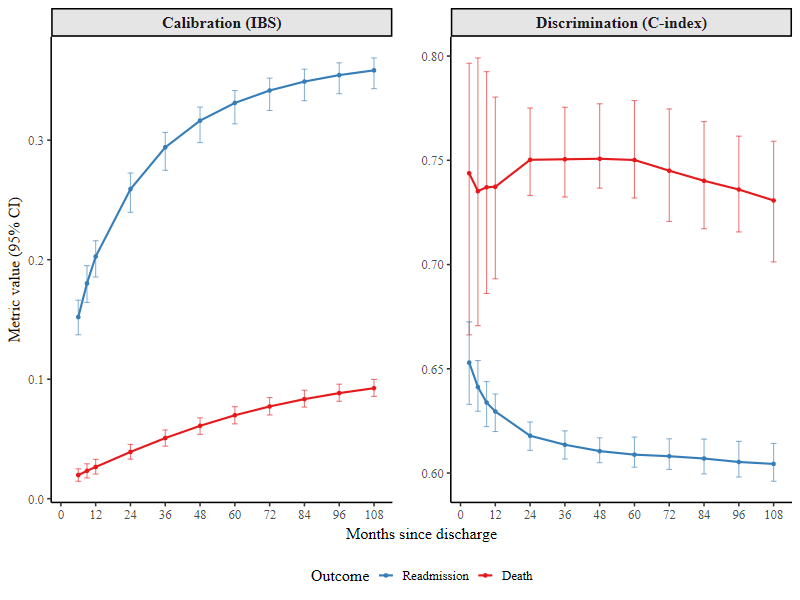

In [41]:
#| label: shap-criteria-dual-cox-plot-python-style-plot-by-time

tnr <- "Times New Roman"
set1_colors <- RColorBrewer::brewer.pal(n = 3, name = "Set1") # Set1 has up to 9 colors, but you only need 2
set1_colors <- rev(set1_colors[1:2])

# Prepare data (ensure proper extraction from results)
time_metrics <- results_shap_xgb_py$summary %>%
  filter(Time != "Global") %>%
  mutate(Time_num = as.numeric(as.character(Time)),
         # Ensure proper ordering of Risk factors
         Risk = factor(Risk, levels = c("Readmission", "Death")))

# Split by metric for separate panels or plots
cindex_data <- time_metrics %>% filter(Metric == "Uno's C-Index")
ibs_data <- time_metrics %>% filter(Metric == "IBS")


p_faceted <- time_metrics %>%
  mutate(Metric = ifelse(Metric == "Uno's C-Index", "Discrimination (C-index)", "Calibration (IBS)")) %>%
  ggplot(aes(x = Time_num, y = mean, color = Risk, fill = Risk)) +
  geom_line(linewidth = 1) +
  geom_point(size = 1.5) +
  geom_errorbar(aes(ymin = q025, ymax = q975), width = 2, alpha = 0.6, size = 0.5) +
  facet_wrap(~Metric, scales = "free_y", ncol = 2) +
  scale_color_manual(values = set1_colors) +
  scale_fill_manual(values = set1_colors) +
  scale_x_continuous(breaks = seq(0, 108, by = 12)) +
  labs(x = "Months since discharge",
       y = "Metric value (95% CI)",
       color = "Outcome",
       fill = "Outcome") +
  theme_classic(base_size = 16, base_family= tnr) +
  theme(legend.position = "bottom",
        strip.background = element_rect(fill = "grey90", color = "black"),
        strip.text = element_text(face = "bold", size = 16),
        panel.spacing = unit(2, "lines"))

p_faceted

In [43]:
#| label: shap-criteria2

gc()
future::plan(future::sequential)
gc()
future::plan(
  future::multisession,
  workers = 8,
  maxSizeOfObjects = 8 * 1024^3
)

results_readmit_shap_ibs <- cph_evaluate_boot_oob_mi_corrected(
    formula = formula_shap_readmit_clean,
    imputed_list = py_corrected_datasets, # List of data.frames
    time_col = "readmit_time_from_disch_m", 
    event_col = "readmit_event",
    tau = 99,                # Evaluate up to 60 months
    B = 500,
    cpus = cpus,
    verbose = TRUE,
    min_strata_events = 1
)
results_death_shap_ibs <- cph_evaluate_boot_oob_mi_corrected(
    formula = formula_shap_death,
    imputed_list = py_corrected_datasets, # List of data.frames
    time_col = "death_time_from_disch_m", 
    event_col = "death_event",
    tau = 107,                # Evaluate up to 60 months
    B = 500,
    cpus = cpus,
    verbose = TRUE,
    min_strata_events = 1
)

aicc_readmit_shap <- compute_mi_aicc(formula_shap_readmit_clean, py_corrected_datasets)#282719.30
cat(sprintf("\nDifference in Mean AIC: %.2f\n", aicc_readmit_shap$mean_aic - aicc_readmit_upd2$mean_aic))
#Difference in Mean AIC: 10170.15
aicc_death_shap <- compute_mi_aicc(formula_shap_death, py_corrected_datasets)
#54321.99
cat(sprintf("\nDifference in Mean AIC: %.2f\n", aicc_death_shap$mean_aic - aicc_death_upd2$mean_aic))
#Difference in Mean AIC: 2825.75
cat("Comparing readmission w/o collinear var and only one strata(plan)\n")
compare_mi_models_d1(formula_readmit_updated,formula_shap_readmit_clean, py_corrected_datasets)

compare_mi_models_d1(formula_death_updated,formula_shap_death, py_corrected_datasets)

Strata variables: plan_type_strata
Categorical vars: plan_type_strata
Bootstrap OOB + MI: B=500, M=5, tau=99.00
Using 8 worker(s)...

FINAL POOLED RESULTS (OOB Bootstrap + MI)
Pooled OOB IBS: 0.3480 (95% CI: 0.3359 - 0.3610)
Valid bootstrap replicates: 500 / 500
Strata variables: plan_type_strata
Categorical vars: plan_type_strata
Bootstrap OOB + MI: B=500, M=5, tau=107.00
Using 8 worker(s)...

FINAL POOLED RESULTS (OOB Bootstrap + MI)
Pooled OOB IBS: 0.0903 (95% CI: 0.0837 - 0.0974)
Valid bootstrap replicates: 500 / 500

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  282719.24
Mean AICc: 282719.30
Correction added (Penalty): 0.066474
Parameters (k): 22 | Effective Sample Size (Events): 15247

Difference in Mean AIC: 10170.15

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  54321.89
Mean AICc: 54321.99
Correction added (Penalty): 0.103106
Parameters (k): 12 | Effective Sample Size (Events): 3039

Difference in Mean AIC: 2825.75
Comparing readmission w/o collinear var and only on

In [44]:
calibrate_cph_grouped_corr <- function(
    formula,
    data,
    times = c(12, 36, 60),
    n_imputations = NULL,
    validation = c("apparent", "cv"),
    folds = 5L,
    n_repeats = 10L,
    g = 10L,
    min_bin_n = 20L,
    compute_ici = FALSE,
    ici_times = NULL,
    ici_df = 4L,
    seed = 2125L,
    ties = "efron",
    verbose = TRUE,
    make_plots = FALSE,
    parallel_cv = TRUE,
    future_scheduling = 2,
    debug_fit = FALSE
) {
    if (!requireNamespace("survival", quietly = TRUE)) {
        stop("Package 'survival' is required.")
    }
    if (isTRUE(compute_ici) && !requireNamespace("splines", quietly = TRUE)) {
        stop("Package 'splines' is required when compute_ici = TRUE.")
    }
    if (isTRUE(make_plots) && !requireNamespace("ggplot2", quietly = TRUE)) {
        stop("Package 'ggplot2' is required when make_plots = TRUE.")
    }
    if (!inherits(formula, "formula")) stop("'formula' must be a formula.")

    validation <- match.arg(validation)

    if (!is.numeric(times) || length(times) == 0L || any(!is.finite(times)) || any(times < 0)) {
        stop("'times' must be a non-empty numeric vector of non-negative finite values.")
    }

    times <- sort(unique(as.numeric(times)))
    folds <- as.integer(folds)
    n_repeats <- as.integer(n_repeats)
    g <- as.integer(g)
    min_bin_n <- as.integer(min_bin_n)
    ici_df <- as.integer(ici_df)
    parallel_cv <- isTRUE(parallel_cv)

    if (is.null(ici_times)) {
        ici_times <- times
    } else {
        if (!is.numeric(ici_times) || any(!is.finite(ici_times))) {
            stop("'ici_times' must be numeric.")
        }
        ici_times <- sort(unique(as.numeric(ici_times)))
    }

    if (any(!ici_times %in% times)) stop("'ici_times' must be a subset of 'times'.")
    if (validation == "cv" && folds < 2L) stop("'folds' must be >= 2 when validation = 'cv'.")
    if (n_repeats < 1L) stop("'n_repeats' must be >= 1.")
    if (g < 1L) stop("'g' must be >= 1.")
    if (min_bin_n < 1L) stop("'min_bin_n' must be >= 1.")
    if (ici_df < 1L) stop("'ici_df' must be >= 1.")

    if (validation == "apparent" && n_repeats != 1L) {
        if (isTRUE(verbose)) {
            message("validation = 'apparent': using a single run and ignoring n_repeats > 1.")
        }
        n_repeats <- 1L
    }

    .msg <- function(...) {
        if (isTRUE(verbose)) message(...)
    }

    .run_stats <- function(x, probs = c(0.025, 0.975), type = 8) {
        x <- x[is.finite(x)]
        n <- length(x)
        if (n == 0L) {
            return(c(
                mean = NA_real_, sd = NA_real_, min = NA_real_,
                p025 = NA_real_, p975 = NA_real_, max = NA_real_, n = 0L
            ))
        }
        q <- stats::quantile(x, probs = c(0, probs, 1), na.rm = TRUE, names = FALSE, type = type)
        c(
            mean = mean(x),
            sd = if (n > 1L) stats::sd(x) else 0,
            min = q[1],
            p025 = q[2],
            p975 = q[3],
            max = q[4],
            n = n
        )
    }

    .qualify_survival_formula_helpers <- function(formula_obj) {
        f_txt <- paste(deparse(formula_obj, width.cutoff = 500L), collapse = " ")

        f_txt <- gsub(
            "(?<![:[:alnum:]_])Surv\\s*\\(",
            "survival::Surv(",
            f_txt,
            perl = TRUE
        )

        f_txt <- gsub(
            "(?<![:[:alnum:]_])strata\\s*\\(",
            "survival::strata(",
            f_txt,
            perl = TRUE
        )

        f_txt
    }

    .parse_surv_formula <- function(formula_obj) {
        surv_call <- formula_obj[[2]]

        if (!inherits(surv_call, "call")) {
            stop("Formula must have a Surv() response.")
        }

        surv_fun <- paste(deparse(surv_call[[1]]), collapse = "")

        if (!(surv_fun %in% c("Surv", "survival::Surv"))) {
            stop("Formula must have a Surv() response variable.")
        }

        if (length(surv_call) != 3L) {
            stop("This function supports only right-censored Surv(time, event) formulas.")
        }

        list(
            time_var  = as.character(surv_call[[2]]),
            event_var = as.character(surv_call[[3]])
        )
    }

    .rhs_formula <- function(formula_obj) {
        f_rhs <- stats::formula(stats::delete.response(stats::terms(formula_obj)))
        environment(f_rhs) <- environment(formula_obj)
        f_rhs
    }

    .as_df_list <- function(x, n_imputations = NULL) {
        if (is.data.frame(x)) {
            out <- list(as.data.frame(x))
        } else if (is.list(x) && length(x) > 0L && all(vapply(x, is.data.frame, logical(1)))) {
            out <- lapply(x, as.data.frame)
        } else {
            stop("'data' must be a data.frame or a list of data.frames.")
        }
        if (!is.null(n_imputations)) {
            out <- out[seq_len(min(as.integer(n_imputations), length(out)))]
        }
        out
    }

    .coerce_event01 <- function(x, varname) {
        if (is.logical(x)) return(as.integer(x))
        if (is.factor(x)) x <- as.character(x)

        if (is.character(x)) {
            out <- rep(NA_integer_, length(x))
            ok <- !is.na(x)
            x0 <- trimws(tolower(x[ok]))
            out_ok <- ifelse(
                x0 %in% c("1", "true", "yes", "y"), 1L,
                ifelse(x0 %in% c("0", "false", "no", "n"), 0L, NA_integer_)
            )
            bad_nonmissing <- is.na(out_ok)
            if (any(bad_nonmissing)) {
                bad_vals <- unique(x[ok][bad_nonmissing])
                stop(
                    "Variable '", varname,
                    "' contains non-missing values that cannot be coerced to 0/1: ",
                    paste(utils::head(bad_vals, 10), collapse = ", ")
                )
            }
            out[ok] <- out_ok
            return(out)
        }

        if (is.numeric(x) || is.integer(x)) {
            ux <- unique(stats::na.omit(x))
            if (!all(ux %in% c(0, 1))) {
                stop("Variable '", varname, "' must contain only 0/1 values (besides NA).")
            }
            return(as.integer(x))
        }

        stop("Variable '", varname, "' must be logical, numeric/integer 0/1, factor, or character.")
    }

    .prepare_survival_data <- function(d, time_var, event_var) {
        req <- c(time_var, event_var)
        miss <- setdiff(req, names(d))
        if (length(miss) > 0L) stop("Missing required columns: ", paste(miss, collapse = ", "))

        tt <- d[[time_var]]
        ee <- .coerce_event01(d[[event_var]], event_var)

        if (!is.numeric(tt)) stop("Time variable must be numeric.")
        if (any(tt < 0, na.rm = TRUE)) stop("Negative follow-up times are not allowed.")

        d$.ftime <- tt
        d$.status <- ee
        d
    }

    .analysis_mask <- function(d0, rhs_formula, time_var, event_var) {
        mf_rhs <- stats::model.frame(rhs_formula, data = d0, na.action = stats::na.pass)
        stats::complete.cases(d0[, c(time_var, event_var, ".ftime", ".status"), drop = FALSE]) &
            stats::complete.cases(mf_rhs)
    }

    .validate_analysis_data <- function(dcc, validation, folds) {
        n <- nrow(dcc)
        n_events <- sum(dcc$.status == 1L, na.rm = TRUE)

        if (n == 0L) stop("No complete cases remain after unified filtering.")
        if (n_events < 1L) stop("No events remain in the analysis cohort.")

        if (validation == "cv") {
            if (folds > n) stop("'folds' cannot exceed the analysis sample size.")
            if (n_events < 2L) stop("Cross-validation is not feasible: fewer than 2 events remain.")
        }

        invisible(TRUE)
    }

    .make_stratified_folds <- function(status, folds, seed_local) {
        set.seed(seed_local)
        n <- length(status)
        if (folds > n) stop("'folds' cannot exceed sample size.")

        fold_id <- integer(n)
        classes <- sort(unique(status))
        offset <- 0L

        for (cl in classes) {
            idx <- which(status == cl)
            idx <- sample(idx, length(idx), replace = FALSE)
            assign <- ((seq_along(idx) - 1L + offset) %% folds) + 1L
            fold_id[idx] <- assign
            offset <- (offset + length(idx)) %% folds
        }

        tab <- tabulate(fold_id, nbins = folds)
        while (any(tab == 0L)) {
            empty_fold <- which(tab == 0L)[1L]
            donor_fold <- which.max(tab)
            donor_idx <- which(fold_id == donor_fold)
            move_idx <- sample(donor_idx, 1L)
            fold_id[move_idx] <- empty_fold
            tab <- tabulate(fold_id, nbins = folds)
        }

        for (k in seq_len(folds)) {
            tr_status <- status[fold_id != k]
            if (sum(tr_status == 1L, na.rm = TRUE) == 0L) {
                stop("Invalid fold split: training fold ", k, " has zero events.")
            }
            if (sum(fold_id == k) == 0L) {
                stop("Invalid fold split: test fold ", k, " is empty.")
            }
        }

        fold_id
    }
    .fit_cox_and_predict_many <- function(
        train_data,
        test_data,
        formula,
        time_var,
        times,
        ties = "efron",
        vars_needed = NULL,
        debug = FALSE
    ) {
        if (is.null(vars_needed)) vars_needed <- unique(all.vars(formula))

        train_data <- train_data[, vars_needed, drop = FALSE]
        test_data  <- test_data[, vars_needed, drop = FALSE]

        if (debug) {
            mf <- stats::model.frame(formula, data = train_data, na.action = stats::na.pass)
            X  <- stats::model.matrix(formula, data = mf)

            inf_cols <- colnames(X)[apply(X, 2, function(z) any(is.infinite(z)))]
            nan_cols <- colnames(X)[apply(X, 2, function(z) any(is.nan(z)))]
            na_cols  <- colnames(X)[apply(X, 2, function(z) any(is.na(z)))]
            const_cols <- apply(X, 2, function(z) length(unique(z[is.finite(z)])) <= 1)
            const_names <- setdiff(colnames(X)[const_cols], "(Intercept)")

            if (length(inf_cols) > 0) message("Inf columns: ", paste(inf_cols, collapse = ", "))
            if (length(nan_cols) > 0) message("NaN columns: ", paste(nan_cols, collapse = ", "))
            if (length(na_cols) > 0)  message("NA columns in model matrix: ", paste(na_cols, collapse = ", "))
            if (length(const_names) > 0) {
                message("Constant non-intercept columns detected: ", paste(const_names, collapse = ", "))
            }
        }

        fit <- survival::coxph(
            formula = formula,
            data = train_data,
            ties = ties,
            x = TRUE,
            y = TRUE,
            model = TRUE
        )

        pred <- sapply(times, function(tt) {
            dtemp <- test_data
            dtemp[[time_var]] <- tt
            cumhaz <- stats::predict(fit, newdata = dtemp, type = "expected")
            risk <- 1 - exp(-cumhaz)
            risk[!is.finite(risk)] <- NA_real_
            pmin(pmax(risk, 0), 1)
        })

        if (is.vector(pred)) pred <- matrix(pred, ncol = 1L)
        colnames(pred) <- paste0("t_", times)
        pred
    }

    .run_one_fold <- function(
        task,
        analysis_data,
        times,
        M,
        formula,
        time_var,
        ties,
        vars_needed,
        debug_fit,
        .fit_fn
    ) {
        tr_idx <- task$tr_idx
        te_idx <- task$te_idx
        pred_sum <- matrix(0, nrow = length(te_idx), ncol = length(times))

        for (m in seq_len(M)) {
            pred_m <- tryCatch(
                .fit_fn(
                    train_data = analysis_data[[m]][tr_idx, , drop = FALSE],
                    test_data  = analysis_data[[m]][te_idx, , drop = FALSE],
                    formula = formula,
                    time_var = time_var,
                    times = times,
                    ties = ties,
                    vars_needed = vars_needed,
                    debug = debug_fit
                ),
                error = function(e) {
                    stop(
                        "Parallel task failed at repetition=", task$r,
                        ", fold=", task$k,
                        ", imputation=", m,
                        ": ", conditionMessage(e),
                        call. = FALSE
                    )
                }
            )
            pred_sum <- pred_sum + pred_m
        }

        list(
            r = task$r,
            te_idx = te_idx,
            pred_fold_avg = pred_sum / M
        )
    }


    .make_cutpoints <- function(x, g = 10L) {
        x <- x[is.finite(x)]
        if (length(x) == 0L) return(numeric(0))
        if (length(unique(x)) == 1L) return(numeric(0))
        probs <- seq(0, 1, length.out = g + 1L)
        q <- stats::quantile(x, probs = probs, na.rm = TRUE, names = FALSE, type = 8)
        unique(q[-c(1, length(q))])
    }

    .assign_bins <- function(x, cutpoints) {
        bins <- rep(NA_integer_, length(x))
        ok <- is.finite(x)
        if (!any(ok)) return(bins)
        if (length(cutpoints) == 0L) {
            bins[ok] <- 1L
        } else {
            bins[ok] <- findInterval(x[ok], vec = cutpoints, all.inside = TRUE) + 1L
        }
        bins
    }

    .build_global_bin_map <- function(x, cutpoints, min_bin_n) {
        bins0 <- .assign_bins(x, cutpoints)
        levs <- sort(unique(stats::na.omit(bins0)))
        if (length(levs) == 0L) return(integer(0))

        groups <- lapply(levs, function(z) z)
        counts_full <- tabulate(bins0[!is.na(bins0)], nbins = max(levs))
        counts <- as.numeric(counts_full[levs])

        repeat {
            n_groups <- length(groups)
            if (n_groups == 1L) break

            small <- which(counts < min_bin_n)
            if (length(small) == 0L) break

            g_idx <- small[1L]
            if (g_idx == 1L) {
                target <- 2L
            } else if (g_idx == n_groups) {
                target <- n_groups - 1L
            } else {
                target <- if (counts[g_idx - 1L] <= counts[g_idx + 1L]) g_idx - 1L else g_idx + 1L
            }

            groups[[target]] <- sort(c(groups[[target]], groups[[g_idx]]))
            counts[target] <- counts[target] + counts[g_idx]

            keep <- setdiff(seq_len(n_groups), g_idx)
            groups <- groups[keep]
            counts <- counts[keep]
        }

        n_orig_bins <- if (length(cutpoints) == 0L) 1L else length(cutpoints) + 1L
        bin_map <- rep(NA_integer_, n_orig_bins)

        if (length(groups) == 1L && counts[1L] < min_bin_n) return(bin_map)

        for (i in seq_along(groups)) {
            bin_map[unlist(groups[[i]], use.names = FALSE)] <- i
        }

        bin_map
    }

    .apply_bin_map <- function(bins, bin_map) {
        out <- rep(NA_integer_, length(bins))
        ok <- !is.na(bins) & bins >= 1L & bins <= length(bin_map)
        if (any(ok)) out[ok] <- bin_map[bins[ok]]
        out
    }

    .km_risk_at_time <- function(time, event, t_horizon) {
        fit <- survival::survfit(survival::Surv(time, event) ~ 1)
        s <- summary(fit, times = t_horizon, extend = TRUE)

        if (length(s$surv) == 0L || is.na(s$surv[1])) {
            return(list(risk = NA_real_, lower = NA_real_, upper = NA_real_))
        }

        surv_t <- as.numeric(s$surv[1])
        lower_s <- if (!is.null(s$lower) && length(s$lower) > 0L) as.numeric(s$lower[1]) else surv_t
        upper_s <- if (!is.null(s$upper) && length(s$upper) > 0L) as.numeric(s$upper[1]) else surv_t

        list(
            risk = 1 - surv_t,
            lower = 1 - upper_s,
            upper = 1 - lower_s
        )
    }

    .grouped_calibration <- function(d, pred_vec, t_horizon, cutpoints, bin_map, min_bin_n) {
        bins0 <- .assign_bins(pred_vec, cutpoints)
        bins <- .apply_bin_map(bins0, bin_map)
        levs <- sort(unique(stats::na.omit(bins)))

        if (length(levs) == 0L) {
            return(list(curve = NULL, n_used = 0L, n_excluded = sum(is.finite(pred_vec))))
        }

        out <- vector("list", length(levs))
        keep_idx <- 0L

        for (b in levs) {
            idx <- which(bins == b)
            if (length(idx) < min_bin_n) next

            km <- .km_risk_at_time(
                time = d$.ftime[idx],
                event = d$.status[idx],
                t_horizon = t_horizon
            )

            keep_idx <- keep_idx + 1L
            out[[keep_idx]] <- data.frame(
                bin = b,
                mean_predicted = mean(pred_vec[idx], na.rm = TRUE),
                observed = km$risk,
                observed_lower = km$lower,
                observed_upper = km$upper,
                n_patients = length(idx),
                stringsAsFactors = FALSE
            )
        }

        if (keep_idx == 0L) {
            return(list(curve = NULL, n_used = 0L, n_excluded = sum(is.finite(pred_vec))))
        }

        curve <- do.call(rbind, out[seq_len(keep_idx)])
        list(
            curve = curve,
            n_used = sum(curve$n_patients),
            n_excluded = sum(is.finite(pred_vec)) - sum(curve$n_patients)
        )
    }
    .smooth_calibration_metrics_surv <- function(d, pred_vec, t_horizon, ici_df = 4L, eps = 1e-06) {
        pred_use <- pmin(pmax(pred_vec, eps), 1 - eps)
        z <- log(-log(1 - pred_use))

        if (any(!is.finite(z))) {
            return(list(
                ici = NA_real_,
                e50 = NA_real_,
                e90 = NA_real_,
                emax = NA_real_,
                smoothed_observed = rep(NA_real_, length(pred_vec))
            ))
        }

        fit_once <- function(df_use) {
            d_fit <- d
            d_fit$.cll_pred <- z

            if (df_use <= 1L || length(unique(z)) <= 3L) {
                f_cal <- survival::Surv(.ftime, .status) ~ .cll_pred
            } else {
                df_eff <- min(as.integer(df_use), length(unique(z)) - 1L)
                basis <- as.data.frame(splines::ns(z, df = df_eff))
                names(basis) <- paste0("ici_s", seq_len(ncol(basis)))
                d_fit[names(basis)] <- basis
                rhs <- paste(names(basis), collapse = " + ")
                f_cal <- stats::as.formula(paste0("survival::Surv(.ftime, .status) ~ ", rhs))
            }

            fit <- survival::coxph(
                formula = f_cal,
                data = d_fit,
                ties = ties,
                x = FALSE,
                y = FALSE,
                model = TRUE
            )

            lp <- stats::predict(fit, newdata = d_fit, type = "lp")
            bh <- survival::basehaz(fit, centered = FALSE)
            H0_t <- stats::approx(
                x = bh$time,
                y = bh$hazard,
                xout = t_horizon,
                method = "constant",
                rule = 2,
                f = 0
            )$y
            risk_t <- 1 - exp(-H0_t * exp(lp))
            list(risk_t = risk_t)
        }

        fit_obj <- tryCatch(
            fit_once(ici_df),
            error = function(e1) {
                tryCatch(
                    fit_once(1L),
                    error = function(e2) {
                        warning("Survival ICI smoother failed at time ", t_horizon, ": ", conditionMessage(e1), call. = FALSE)
                        NULL
                    }
                )
            }
        )

        if (is.null(fit_obj)) {
            return(list(
                ici = NA_real_,
                e50 = NA_real_,
                e90 = NA_real_,
                emax = NA_real_,
                smoothed_observed = rep(NA_real_, length(pred_vec))
            ))
        }

        obs_smooth <- fit_obj$risk_t

        if (length(obs_smooth) != length(pred_vec) || any(!is.finite(obs_smooth))) {
            warning("Survival ICI prediction failed at time ", t_horizon, ".", call. = FALSE)
            return(list(
                ici = NA_real_,
                e50 = NA_real_,
                e90 = NA_real_,
                emax = NA_real_,
                smoothed_observed = rep(NA_real_, length(pred_vec))
            ))
        }

        abs_err <- abs(obs_smooth - pred_vec)

        list(
            ici = mean(abs_err, na.rm = TRUE),
            e50 = as.numeric(stats::quantile(abs_err, probs = 0.50, na.rm = TRUE, names = FALSE, type = 8)),
            e90 = as.numeric(stats::quantile(abs_err, probs = 0.90, na.rm = TRUE, names = FALSE, type = 8)),
            emax = max(abs_err, na.rm = TRUE),
            smoothed_observed = obs_smooth
        )
    }

    .pool_summary <- function(by_repetition) {
        if (nrow(by_repetition) == 0L) return(by_repetition)

        time_levels <- sort(unique(by_repetition$time_months))
        out <- lapply(time_levels, function(tt) {
            z <- by_repetition[by_repetition$time_months == tt, , drop = FALSE]

            ici_st <- .run_stats(z$ici)
            e50_st <- .run_stats(z$e50)
            e90_st <- .run_stats(z$e90)
            emax_st <- .run_stats(z$emax)
            ece_st <- .run_stats(z$ece)
            eo_st <- .run_stats(z$eo_ratio)
            mp_st <- .run_stats(z$mean_predicted)
            obs_st <- .run_stats(z$observed)

            data.frame(
                time_months = tt,
                ici_mean = unname(ici_st["mean"]),
                ici_sd = unname(ici_st["sd"]),
                ici_min = unname(ici_st["min"]),
                ici_p025 = unname(ici_st["p025"]),
                ici_p975 = unname(ici_st["p975"]),
                ici_max = unname(ici_st["max"]),
                e50_mean = unname(e50_st["mean"]),
                e50_sd = unname(e50_st["sd"]),
                e50_min = unname(e50_st["min"]),
                e50_p025 = unname(e50_st["p025"]),
                e50_p975 = unname(e50_st["p975"]),
                e50_max = unname(e50_st["max"]),
                e90_mean = unname(e90_st["mean"]),
                e90_sd = unname(e90_st["sd"]),
                e90_min = unname(e90_st["min"]),
                e90_p025 = unname(e90_st["p025"]),
                e90_p975 = unname(e90_st["p975"]),
                e90_max = unname(e90_st["max"]),
                emax_mean = unname(emax_st["mean"]),
                emax_sd = unname(emax_st["sd"]),
                emax_min = unname(emax_st["min"]),
                emax_p025 = unname(emax_st["p025"]),
                emax_p975 = unname(emax_st["p975"]),
                emax_max = unname(emax_st["max"]),
                ece_mean = unname(ece_st["mean"]),
                ece_sd = unname(ece_st["sd"]),
                ece_min = unname(ece_st["min"]),
                ece_p025 = unname(ece_st["p025"]),
                ece_p975 = unname(ece_st["p975"]),
                ece_max = unname(ece_st["max"]),
                eo_mean = unname(eo_st["mean"]),
                eo_sd = unname(eo_st["sd"]),
                eo_min = unname(eo_st["min"]),
                eo_p025 = unname(eo_st["p025"]),
                eo_p975 = unname(eo_st["p975"]),
                eo_max = unname(eo_st["max"]),
                mean_pred = unname(mp_st["mean"]),
                mean_pred_sd = unname(mp_st["sd"]),
                mean_pred_min = unname(mp_st["min"]),
                mean_pred_p025 = unname(mp_st["p025"]),
                mean_pred_p975 = unname(mp_st["p975"]),
                mean_pred_max = unname(mp_st["max"]),
                observed = unname(obs_st["mean"]),
                observed_sd = unname(obs_st["sd"]),
                observed_min = unname(obs_st["min"]),
                observed_p025 = unname(obs_st["p025"]),
                observed_p975 = unname(obs_st["p975"]),
                observed_max = unname(obs_st["max"]),
                n_runs = nrow(z),
                n_imp = M,
                stringsAsFactors = FALSE
            )
        })

        out <- do.call(rbind, out)
        rownames(out) <- NULL
        out[order(out$time_months), , drop = FALSE]
    }

    .pool_curves <- function(curves_df) {
        if (nrow(curves_df) == 0L) return(curves_df)

        key <- paste(curves_df$time_months, curves_df$bin, sep = "___")
        spl <- split(curves_df, key)

        out <- lapply(spl, function(z) {
            mp_st <- .run_stats(z$mean_predicted)
            obs_st <- .run_stats(z$observed)
            low_st <- .run_stats(z$observed_lower)
            upp_st <- .run_stats(z$observed_upper)

            data.frame(
                time_months = unique(z$time_months),
                bin = unique(z$bin),
                mean_predicted = unname(mp_st["mean"]),
                mean_predicted_sd = unname(mp_st["sd"]),
                mean_predicted_min = unname(mp_st["min"]),
                mean_predicted_p025 = unname(mp_st["p025"]),
                mean_predicted_p975 = unname(mp_st["p975"]),
                mean_predicted_max = unname(mp_st["max"]),
                observed = unname(obs_st["mean"]),
                observed_sd = unname(obs_st["sd"]),
                observed_min = unname(obs_st["min"]),
                observed_p025 = unname(obs_st["p025"]),
                observed_p975 = unname(obs_st["p975"]),
                observed_max = unname(obs_st["max"]),
                observed_lower = unname(low_st["mean"]),
                observed_upper = unname(upp_st["mean"]),
                n_total = sum(z$n_patients, na.rm = TRUE),
                n_runs = nrow(z),
                n_imp = M,
                stringsAsFactors = FALSE
            )
        })

        out <- do.call(rbind, out)
        rownames(out) <- NULL
        out[order(out$time_months, out$bin), , drop = FALSE]
    }

    formula_txt <- .qualify_survival_formula_helpers(formula)
    formula_eval <- stats::as.formula(formula_txt, env = environment(formula))

    surv_info <- .parse_surv_formula(formula_eval)
    time_var <- surv_info$time_var
    event_var <- surv_info$event_var
    rhs_formula <- .rhs_formula(formula_eval)
    vars_needed <- unique(all.vars(formula_eval))

    data_list <- .as_df_list(data, n_imputations = n_imputations)
    M <- length(data_list)
    effective_repeats <- if (validation == "cv") n_repeats else 1L

    .msg("Detected time variable: ", time_var)
    .msg("Detected event variable: ", event_var)
    .msg("Using ", M, " imputed dataset(s).")
    .msg("Validation: ", validation)
    if (validation == "cv") {
        .msg("Repetitions: ", effective_repeats, " | same fold split across imputations within each repetition.")
    }
    if (isTRUE(compute_ici)) {
        .msg("ICI: enabled at horizons ", paste(ici_times, collapse = ", "), ".")
    } else {
        .msg("ICI: disabled.")
    }

    d0_list <- lapply(data_list, function(dd) {
        .prepare_survival_data(as.data.frame(dd), time_var, event_var)
    })

    if (M > 1L) {
        ref0 <- d0_list[[1L]]
        for (m in 2:M) {
            if (nrow(d0_list[[m]]) != nrow(ref0)) {
                stop("All imputations must have the same number of rows and row order.")
            }
            same_time <- isTRUE(all.equal(ref0$.ftime, d0_list[[m]]$.ftime, tolerance = 1e-08, check.attributes = FALSE))
            same_status <- identical(ref0$.status, d0_list[[m]]$.status)
            if (!same_time || !same_status) {
                stop("Outcome/time information differs across imputations. This workflow assumes only predictors were imputed.")
            }
        }
    }

    mask_list <- lapply(d0_list, function(d0) .analysis_mask(d0, rhs_formula, time_var, event_var))
    keep_all <- Reduce(`&`, mask_list)

    n_input <- nrow(d0_list[[1L]])
    n_analysis <- sum(keep_all)
    n_dropped <- n_input - n_analysis

    if (n_dropped > 0L) {
        .msg("Dropping ", n_dropped, " rows due to missing outcomes/times/model covariates in at least one imputation.")
    }

    analysis_data <- lapply(d0_list, function(d0) {
        out <- d0[keep_all, , drop = FALSE]
        rownames(out) <- NULL
        out
    })

    reference_data <- analysis_data[[1L]]
    .validate_analysis_data(reference_data, validation, folds)

    n_events_total <- sum(reference_data$.status == 1L, na.rm = TRUE)

    reference_observed <- do.call(rbind, lapply(times, function(tt) {
        km <- .km_risk_at_time(reference_data$.ftime, reference_data$.status, tt)
        data.frame(
            time_months = tt,
            observed = km$risk,
            observed_lower = km$lower,
            observed_upper = km$upper,
            stringsAsFactors = FALSE
        )
    }))

    pred_rep_list <- list()

    if (validation == "apparent") {
        .msg("Fitting apparent predictions averaged across imputations...", appendLF = FALSE)

        pred_sum <- matrix(0, nrow = n_analysis, ncol = length(times))
        for (m in seq_len(M)) {
            pred_m <- .fit_cox_and_predict_many(
                train_data = analysis_data[[m]],
                test_data = analysis_data[[m]],
                formula_txt = formula_txt,
                time_var = time_var,
                times = times,
                ties = ties,
                vars_needed = vars_needed,
                debug = debug_fit
            )
            pred_sum <- pred_sum + pred_m
        }

        pred_avg <- pred_sum / M
        colnames(pred_avg) <- paste0("t_", times)
        pred_rep_list[[1L]] <- list(repetition = 1L, pred = pred_avg)

        .msg(" done")
    } else {
        task_list <- unlist(
            lapply(seq_len(effective_repeats), function(r) {
                fold_id <- .make_stratified_folds(
                    reference_data$.status,
                    folds = folds,
                    seed_local = seed + r
                )
                lapply(seq_len(folds), function(k) {
                    list(
                        r = r,
                        k = k,
                        tr_idx = which(fold_id != k),
                        te_idx = which(fold_id == k)
                    )
                })
            }),
            recursive = FALSE
        )

        if (parallel_cv) {
            if (!requireNamespace("future.apply", quietly = TRUE)) {
                stop("Package 'future.apply' is required when parallel_cv = TRUE.")
            }

            .msg(
                "Running CV predictions in parallel across ",
                length(task_list),
                " repetition x fold tasks...",
                appendLF = FALSE
            )

            task_results <- future.apply::future_lapply(
                X = task_list,
                FUN = .run_one_fold,
                analysis_data = analysis_data,
                times = times,
                M = M,
                formula = formula_eval,
                time_var = time_var,
                ties = ties,
                vars_needed = vars_needed,
                debug_fit = debug_fit,
                .fit_fn = .fit_cox_and_predict_many,
                future.seed = TRUE,
                future.globals = FALSE,
                future.packages = c("survival", "splines"),
                future.scheduling = future_scheduling
            )
            .msg(" done")
        } else {
            .msg(
                "Running CV predictions sequentially across ",
                length(task_list),
                " repetition x fold tasks...",
                appendLF = FALSE
            )

            task_results <- lapply(
                X = task_list,
                FUN = .run_one_fold,
                analysis_data = analysis_data,
                times = times,
                M = M,
                formula = formula_eval,
                time_var = time_var,
                ties = ties,
                vars_needed = vars_needed,
                debug_fit = debug_fit,
                .fit_fn = .fit_cox_and_predict_many
            )

            .msg(" done")
        }

        for (r in seq_len(effective_repeats)) {
            pred_avg <- matrix(NA_real_, nrow = n_analysis, ncol = length(times))
            r_hits <- task_results[vapply(task_results, function(x) x$r, integer(1L)) == r]

            for (res in r_hits) {
                pred_avg[res$te_idx, ] <- res$pred_fold_avg
            }

            if (any(!is.finite(pred_avg))) {
                stop("Non-finite predictions remained after averaging across imputations in repetition ", r, ".")
            }

            colnames(pred_avg) <- paste0("t_", times)
            pred_rep_list[[length(pred_rep_list) + 1L]] <- list(repetition = r, pred = pred_avg)
        }
    }

    common_cutpoints <- vector("list", length(times))
    common_bin_maps <- vector("list", length(times))
    names(common_cutpoints) <- paste0("t_", times)
    names(common_bin_maps) <- paste0("t_", times)

    for (j in seq_along(times)) {
        pooled_preds_j <- unlist(lapply(pred_rep_list, function(obj) obj$pred[, j]), use.names = FALSE)
        cuts_j <- .make_cutpoints(pooled_preds_j, g = g)
        common_cutpoints[[j]] <- cuts_j
        common_bin_maps[[j]] <- .build_global_bin_map(
            x = pooled_preds_j,
            cutpoints = cuts_j,
            min_bin_n = min_bin_n
        )
    }

    curves_all <- list()
    metrics_all <- list()

    for (rep_idx in seq_along(pred_rep_list)) {
        rep_obj <- pred_rep_list[[rep_idx]]
        r <- rep_obj$repetition
        pred_r <- rep_obj$pred

        .msg("Calibrating repetition ", r, "/", length(pred_rep_list), "...", appendLF = FALSE)

        for (j in seq_along(times)) {
            t_horizon <- times[j]
            pred_vec <- pred_r[, j]

            calib_obj <- .grouped_calibration(
                d = reference_data,
                pred_vec = pred_vec,
                t_horizon = t_horizon,
                cutpoints = common_cutpoints[[j]],
                bin_map = common_bin_maps[[j]],
                min_bin_n = min_bin_n
            )

            calib_df <- calib_obj$curve

            if (is.null(calib_df) || nrow(calib_df) == 0L) {
                warning("No calibration bins survived for repetition ", r, " at time ", t_horizon, ".", call. = FALSE)
                next
            }

            obs_row <- reference_observed[reference_observed$time_months == t_horizon, , drop = FALSE]
            ece <- stats::weighted.mean(
                abs(calib_df$mean_predicted - calib_df$observed),
                w = calib_df$n_patients,
                na.rm = TRUE
            )

            if (isTRUE(compute_ici) && t_horizon %in% ici_times) {
                ici_obj <- .smooth_calibration_metrics_surv(
                    d = reference_data,
                    pred_vec = pred_vec,
                    t_horizon = t_horizon,
                    ici_df = ici_df
                )
            } else {
                ici_obj <- list(
                    ici = NA_real_,
                    e50 = NA_real_,
                    e90 = NA_real_,
                    emax = NA_real_
                )
            }

            mean_pred <- mean(pred_vec, na.rm = TRUE)
            eo_ratio <- if (is.na(obs_row$observed[1]) || obs_row$observed[1] <= 0) {
                NA_real_
            } else {
                mean_pred / obs_row$observed[1]
            }
            n_events <- sum(reference_data$.ftime <= t_horizon & reference_data$.status == 1L, na.rm = TRUE)

            calib_df$repetition <- r
            calib_df$time_months <- t_horizon
            curves_all[[length(curves_all) + 1L]] <- calib_df

            metrics_all[[length(metrics_all) + 1L]] <- data.frame(
                repetition = r,
                time_months = t_horizon,
                ici = ici_obj$ici,
                e50 = ici_obj$e50,
                e90 = ici_obj$e90,
                emax = ici_obj$emax,
                ece = ece,
                eo_ratio = eo_ratio,
                mean_predicted = mean_pred,
                observed = obs_row$observed[1],
                observed_lower = obs_row$observed_lower[1],
                observed_upper = obs_row$observed_upper[1],
                n_input = n_input,
                n_analysis = n_analysis,
                n_dropped = n_dropped,
                n_events = n_events,
                n_events_total = n_events_total,
                n_used_calibration = calib_obj$n_used,
                n_excluded_calibration = calib_obj$n_excluded,
                n_bins = nrow(calib_df),
                n_imputations = M,
                stringsAsFactors = FALSE
            )
        }

        .msg(" done")
    }

    by_repetition <- if (length(metrics_all) > 0L) do.call(rbind, metrics_all) else data.frame()
    curves_df <- if (length(curves_all) > 0L) do.call(rbind, curves_all) else data.frame()

    if (isTRUE(compute_ici) && nrow(by_repetition) > 0L) {
        ici_rows <- by_repetition$time_months %in% ici_times
        if (any(ici_rows) && all(is.na(by_repetition$ici[ici_rows]))) {
            warning("ICI/E50/E90/Emax could not be computed for the requested ICI horizons.", call. = FALSE)
        }
    }

    pooled_summary <- if (nrow(by_repetition) > 0L) .pool_summary(by_repetition) else data.frame()
    pooled_curves <- if (nrow(curves_df) > 0L) .pool_curves(curves_df) else data.frame()

    plot_list <- list()
    combined_plot <- NULL

    if (isTRUE(make_plots) && nrow(pooled_curves) > 0L) {
        event_label <- gsub("_", " ", event_var)

        for (tt in times) {
            pdat <- pooled_curves[pooled_curves$time_months == tt, , drop = FALSE]
            rdat <- curves_df[curves_df$time_months == tt, , drop = FALSE]
            if (nrow(pdat) == 0L) next

            lim_max <- max(
                c(rdat$mean_predicted, rdat$observed, pdat$mean_predicted_p975, pdat$observed_p975),
                na.rm = TRUE
            )
            lim_max <- max(0.05, lim_max * 1.05)

            srow <- pooled_summary[pooled_summary$time_months == tt, , drop = FALSE]
            subtxt <- if (nrow(srow) == 1L) {
                paste0(
                    "Validation: ", validation,
                    if (validation == "cv") paste0(" | repetitions = ", effective_repeats) else "",
                    if (M > 1L) paste0(" | imputations averaged = ", M) else "",
                    if (isTRUE(compute_ici) && tt %in% ici_times) {
                        paste0(
                            " | ICI mean = ", formatC(srow$ici_mean, digits = 4, format = "f"),
                            " | SD = ", formatC(srow$ici_sd, digits = 4, format = "f")
                        )
                    } else {
                        " | ICI not computed"
                    },
                    " | E/O mean = ", formatC(srow$eo_mean, digits = 4, format = "f"),
                    " | SD = ", formatC(srow$eo_sd, digits = 4, format = "f")
                )
            } else {
                paste0("Validation: ", validation)
            }

            p <- ggplot2::ggplot() +
                ggplot2::geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +
                ggplot2::geom_line(
                    data = rdat,
                    ggplot2::aes(x = mean_predicted, y = observed, group = repetition),
                    color = "gray70",
                    alpha = 0.55,
                    linewidth = 0.4
                ) +
                ggplot2::geom_ribbon(
                    data = pdat,
                    ggplot2::aes(x = mean_predicted, ymin = observed_p025, ymax = observed_p975, group = 1),
                    fill = "gray70",
                    alpha = 0.25
                ) +
                ggplot2::geom_line(
                    data = pdat,
                    ggplot2::aes(x = mean_predicted, y = observed, group = 1),
                    color = "steelblue",
                    linewidth = 0.9
                ) +
                ggplot2::geom_point(
                    data = pdat,
                    ggplot2::aes(x = mean_predicted, y = observed),
                    size = 2.5,
                    shape = 21,
                    fill = "white",
                    color = "steelblue"
                ) +
                ggplot2::coord_equal(xlim = c(0, lim_max), ylim = c(0, lim_max)) +
                ggplot2::labs(
                    title = paste0(tt, " months"),
                    subtitle = subtxt,
                    x = paste0("Predicted probability of ", event_label),
                    y = paste0("Observed KM risk of ", event_label)
                ) +
                ggplot2::theme_minimal()

            plot_list[[paste0("month_", tt)]] <- p
        }

        combined_plot <- ggplot2::ggplot() +
            ggplot2::geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +
            ggplot2::geom_line(
                data = curves_df,
                ggplot2::aes(x = mean_predicted, y = observed, group = interaction(time_months, repetition)),
                color = "gray70",
                alpha = 0.5,
                linewidth = 0.35
            ) +
            ggplot2::geom_ribbon(
                data = pooled_curves,
                ggplot2::aes(x = mean_predicted, ymin = observed_p025, ymax = observed_p975, group = time_months),
                fill = "gray70",
                alpha = 0.25
            ) +
            ggplot2::geom_line(
                data = pooled_curves,
                ggplot2::aes(x = mean_predicted, y = observed, group = time_months),
                color = "steelblue",
                linewidth = 0.85
            ) +
            ggplot2::geom_point(
                data = pooled_curves,
                ggplot2::aes(x = mean_predicted, y = observed),
                size = 1.8,
                color = "steelblue"
            ) +
            ggplot2::facet_wrap(~time_months, scales = "free") +
            ggplot2::labs(
                title = paste0("Grouped calibration of Cox predictions for ", event_label),
                subtitle = paste0(
                    "Gray lines = repetitions | Gray ribbon = pointwise 2.5th-97.5th percentile across repetitions | Blue = mean",
                    if (validation == "cv") paste0(" | repeated ", folds, "-fold CV x ", effective_repeats) else ""
                ),
                x = paste0("Predicted probability of ", event_label),
                y = paste0("Observed KM risk of ", event_label)
            ) +
            ggplot2::theme_minimal()
    }

    structure(
        list(
            by_repetition = by_repetition,
            by_run = by_repetition,
            pooled_summary = pooled_summary,
            calibration_curves = pooled_curves,
            raw_curves = curves_df,
            reference_observed = reference_observed,
            plots = plot_list,
            combined_plot = combined_plot,
            cutpoints = common_cutpoints,
            bin_maps = common_bin_maps,
            variable_names = list(time = time_var, event = event_var),
            settings = list(
                times = times,
                n_imputations = M,
                validation = validation,
                folds = if (validation == "cv") folds else NA_integer_,
                n_repeats = effective_repeats,
                n_runs_total = effective_repeats,
                g = g,
                min_bin_n = min_bin_n,
                compute_ici = isTRUE(compute_ici),
                ici_times = ici_times,
                ici_df = ici_df,
                ties = ties,
                parallel_cv = parallel_cv,
                future_scheduling = future_scheduling,
                debug_fit = debug_fit,
                workflow = "parallel by repetition x fold; average held-out predictions across imputations; variability across repetitions"
            )
        ),
        class = "cph_grouped_calibration_corr"
    )
}

print.cph_grouped_calibration_corr <- function(x, ...) {
    cat("<cph_grouped_calibration_corr>\n\n")
    cat("$pooled_summary\n")
    print.data.frame(x$pooled_summary, row.names = FALSE)
    invisible(x)
}

In [45]:
#| label: shap-criteria3

gc()
cal_readmit_shap<- 
  calibrate_cph_grouped_corr(
    formula = formula_shap_readmit_clean, # Original formula with months variable
    data = py_corrected_datasets, # Original data (months)
    times = c(12, 36, 60, 96),
    seed = 2125,
    validation = "cv",
    n_repeats = 20,
    n_imputations = 5,
    compute_ici = TRUE,
    ici_times = 60,
    make_plots = TRUE,
    parallel_cv = T,
    future_scheduling = 2,
    debug_fit = T
)
print(cal_readmit_shap)

cal_death_shap<- 
    calibrate_cph_grouped_corr(
    formula = formula_shap_death, # Original formula with months variable
    data = py_corrected_datasets, # Original data (months)
    times = c(12, 36, 60, 96),
    seed = 2125,
    validation = "cv",
    n_repeats = 20,
    n_imputations = 5,
    compute_ici = TRUE,
    ici_times = 60,
    make_plots = TRUE,
    parallel_cv = T,
    future_scheduling = 2,
    debug_fit = T
)
print(cal_death_shap)

Detected time variable: readmit_time_from_disch_m
Detected event variable: readmit_event
Using 5 imputed dataset(s).
Validation: cv
Repetitions: 20 | same fold split across imputations within each repetition.
ICI: enabled at horizons 60.
Running CV predictions in parallel across 100 repetition x fold tasks... done
Calibrating repetition 1/20... done
Calibrating repetition 2/20... done
Calibrating repetition 3/20... done
Calibrating repetition 4/20... done
Calibrating repetition 5/20... done
Calibrating repetition 6/20... done
Calibrating repetition 7/20... done
Calibrating repetition 8/20... done
Calibrating repetition 9/20... done
Calibrating repetition 10/20... done
Calibrating repetition 11/20... done
Calibrating repetition 12/20... done
Calibrating repetition 13/20... done
Calibrating repetition 14/20... done
Calibrating repetition 15/20... done
Calibrating repetition 16/20... done
Calibrating repetition 17/20... done
Calibrating repetition 18/20... done
Calibrating repetition 19/2

In [46]:
#| label: shap-criteria-nph

cox.zph(coxph(formula_shap_death, data= py_corrected_datasets[[1]]))

                                        chisq df        p
adm_age_rec3                            0.510  1  0.47509
primary_sub_mod_cocaine_paste           1.640  1  0.20030
prim_sub_freq_rec_2_2_6_days_wk         1.000  1  0.31738
prim_sub_freq_rec_3_daily               1.750  1  0.18593
occupation_condition_corr24_unemployed  1.426  1  0.23238
any_phys_dx                            15.394  1 0.000087
eva_ocupacion_logro_intermedio          0.540  1  0.46247
eva_ocupacion_logro_minimo              3.688  1  0.05481
first_sub_used_alcohol                  0.510  1  0.47531
sex_rec_woman                           0.422  1  0.51597
eva_fisica_logro_intermedio             2.624  1  0.10526
eva_fisica_logro_minimo                11.163  1  0.00083
GLOBAL                                 33.829 12  0.00072

In [47]:
#| label: shap-criteria-nph2

cox.zph(coxph(formula_shap_readmit_clean, data= py_corrected_datasets[[1]]))

                                                         chisq df       p
primary_sub_mod_cocaine_paste                           0.1033  1 0.74795
adm_age_rec3                                            5.5339  1 0.01865
porc_pobr                                               0.4708  1 0.49262
sex_rec_woman                                           1.0806  1 0.29857
ethnicity                                               4.3431  1 0.03716
dit_m                                                  21.5576  1 3.4e-06
eva_consumo_logro_intermedio                            1.5075  1 0.21953
eva_consumo_logro_minimo                                6.2784  1 0.01222
ed_attainment_corr_2_completed_high_school_or_less      8.0121  1 0.00465
ed_attainment_corr_3_completed_primary_school_or_less  11.6986  1 0.00063
sub_dep_icd10_status_drug_dependence                    2.5565  1 0.10984
occupation_condition_corr24_unemployed                  0.0845  1 0.77127
polysubstance_strict                  

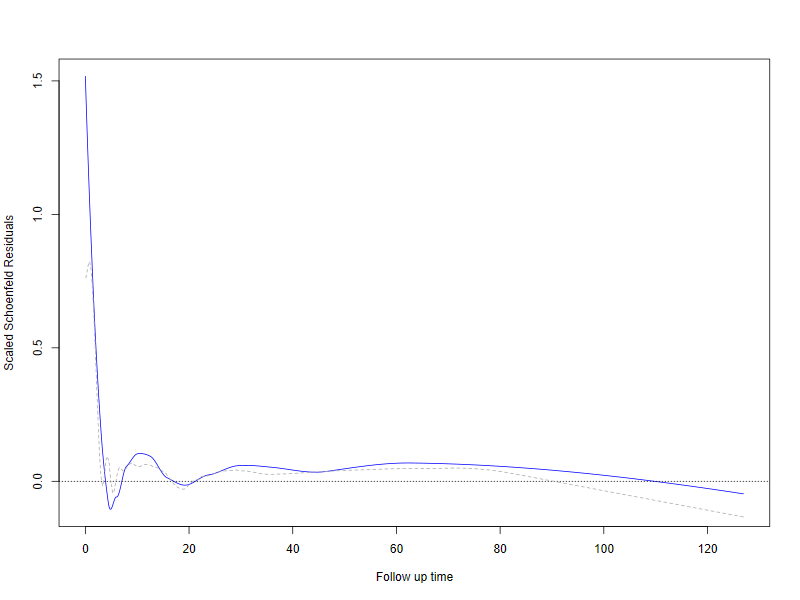

In [48]:
#| label: shap-criteria-nph4-plot-readm-additional-strata

res <- resid(coxph(formula_shap_readmit_clean, data = py_corrected_datasets[[1]]),
                "scaledsch")

time <- as.numeric(rownames(res))
y <- res[, "tr_outcome_adm_discharge_rule_violation_undet"]

z2 <- loess(y ~ time, span = 0.50)
ord <- order(time)

plot(time[ord], fitted(z2)[ord], type = "l", col = "blue",
     xlab = "Follow up time",
     ylab = "Scaled Schoenfeld Residuals")
abline(h = 0, lty = 3)

ss <- supsmu(time, y)
lines(ss$x, ss$y, lty = 2, col = "darkgray")


In [49]:
formula_shap_readmit_clean_updated

Surv(readmit_time_from_disch_m, readmit_event) ~ primary_sub_mod_cocaine_paste + 
    adm_age_rec3 + porc_pobr + sex_rec_woman + ethnicity + dit_m + 
    eva_consumo_logro_intermedio + eva_consumo_logro_minimo + 
    ed_attainment_corr_2_completed_high_school_or_less + ed_attainment_corr_3_completed_primary_school_or_less + 
    sub_dep_icd10_status_drug_dependence + occupation_condition_corr24_unemployed + 
    polysubstance_strict + primary_sub_mod_cocaine_powder + evaluacindelprocesoteraputico_logro_intermedio + 
    dg_psiq_cie_10_dg + eva_sm_logro_intermedio + eva_sm_logro_minimo + 
    prim_sub_freq_rec_2_2_6_days_wk + prim_sub_freq_rec_3_daily + 
    primary_sub_mod_alcohol + strata(plan_type_strata) + strat(tr_outcome_adm_discharge_rule_violation_undet)

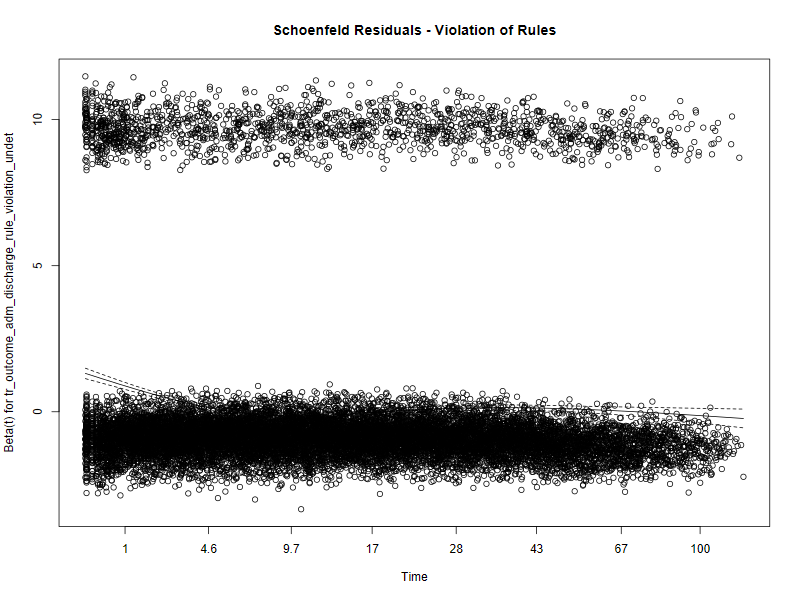

In [50]:
fit <- coxph(formula_shap_readmit_clean, data = py_corrected_datasets[[1]])
zph <- cox.zph(fit, transform = "km")  # or "rank", "identity"

# Plot with confidence bands
plot(zph, var = "tr_outcome_adm_discharge_rule_violation_undet", 
     main = "Schoenfeld Residuals - Violation of Rules")

In [51]:
#Function to print results in a nice format
source(paste0(project_root,"/cons/_alt_scripts/print_results_readmit_shap.R"))

#prs(results_readmit_shap)

print_results_readmit_shap.R loaded. Functions: print_pooled_results, view_pooled_results, prs


### Additional strata to readmission

In [52]:
#| label: shap-criteria-additional-strata2

gc()

results_readmit_shap2 <- evaluate_mi_cv_safe_strata(
  formula = as.formula(
  gsub(
    "strat\\(",
    "strata(",
    paste(deparse(formula_shap_readmit_clean_updated), collapse = " ")
  )
), 
  imputed_list = py_corrected_datasets, 
  time_col = "readmit_time_from_disch_m", 
  event_col = "readmit_event",
  k = 5,
  n_repeats = 20
)

Starting Evaluation: 5 Imputations x 5 Folds x 20 Repeats = 500 Total Models
------------------------------------------------------------
Global evaluation tau: 99.10 months | C-tau: 94.14 months
Booting up 16 CPU cores using future backend...

FINAL POOLED RESULTS (Cross-Validated + Multiply Imputed)
Global Evaluation Time (tau): 99.10 months
Pooled Uno's C-Index: 0.6058 (repeat-quantile interval 0.6056-0.6061)
Pooled UnoC (survAUC::UnoC): 0.6784 (repeat-quantile interval 0.6473-0.6962)
Pooled IBS: 0.1602 (repeat-quantile interval 0.1601-0.1602)
Pooled IBS (IPCW-train): 0.3481 (repeat-quantile interval 0.3479-0.3483)
RMST-based Uno C-index by horizon:
  t=12 m: C=0.6294 (repeat-quantile interval 0.6291-0.6296, valid repeats=20)
  t=36 m: C=0.6135 (repeat-quantile interval 0.6133-0.6138, valid repeats=20)
  t=60 m: C=0.6087 (repeat-quantile interval 0.6085-0.6090, valid repeats=20)

Total runtime: 214.33 sec (3.57 min)


In [53]:
#| label: shap-criteria-additional-strata22

results_readmit_shap_ibs <- cph_evaluate_boot_oob_mi_corrected(
  formula = as.formula(gsub("strat\\(", "strata(", deparse(formula_shap_readmit_clean_updated))),
  imputed_list = py_corrected_datasets, # List of data.frames
  time_col = "readmit_time_from_disch_m", 
  event_col = "readmit_event",
  tau = 99,                # Evaluate up to 60 months
  B = 500,
  cpus = cpus,
  verbose = TRUE,
  min_strata_events = 1
)

aicc_readmit_shap <- compute_mi_aicc(as.formula(gsub("strat\\(", "strata(", deparse(formula_shap_readmit_clean_updated))), py_corrected_datasets)
cat(sprintf("\nDifference in Mean AIC: %.2f\n", aicc_readmit_shap$mean_aic - aicc_readmit_upd2$mean_aic))

Strata variables: plan_type_strata, tr_outcome_adm_discharge_rule_violation_undet
Categorical vars: plan_type_strata, tr_outcome_adm_discharge_rule_violation_undet
Bootstrap OOB + MI: B=500, M=5, tau=99.00
Using 8 worker(s)...

FINAL POOLED RESULTS (OOB Bootstrap + MI)
Pooled OOB IBS: 0.3479 (95% CI: 0.3357 - 0.3609)
Valid bootstrap replicates: 500 / 500


Warning message:
In formula.character(object, env = baseenv()) :
  Using formula(x) is deprecated when x is a character vector of length > 1.
  Consider formula(paste(x, collapse = " ")) instead.



AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272588.32
Mean AICc: 272588.38
Correction added (Penalty): 0.060690
Parameters (k): 21 | Effective Sample Size (Events): 15247


Warning message:
In formula.character(object, env = baseenv()) :
  Using formula(x) is deprecated when x is a character vector of length > 1.
  Consider formula(paste(x, collapse = " ")) instead.



Difference in Mean AIC: 39.23


In [54]:
compare_mi_models_d1(formula_shap_readmit_clean_updated,formula_shap_readmit_clean, py_corrected_datasets)

Fitting the FULL model on 5 imputations...
Fitting the REDUCED model on 5 imputations...
Executing the Wald Test (D1)...

MODEL COMPARISON RESULT (D1 Statistic)
   test statistic df1 df2 dfcom     p.value           riv
 1 ~~ 2  47.39744   1   4 15225 0.002332909 0.00001724682


In [55]:
#| label: shap-criteria-additional-strata23

gc()
future::plan(future::sequential)
gc()
future::plan(
  future::multisession,
  workers = 8,
  maxSizeOfObjects = 8 * 1024^3
)

cal_readmit_shap2<- 
  calibrate_cph_grouped_corr(
    formula = as.formula(gsub("strat\\(", "strata(", deparse(formula_shap_readmit_clean_updated))),  # Original formula with months variable
    data = py_corrected_datasets, # Original data (months)
    times = c(12, 36, 60, 96),
    seed = 2125,
    validation = "cv",
    n_repeats = 20,
    n_imputations = 5,
    compute_ici = TRUE,
    ici_times = 60,
    make_plots = TRUE,
    parallel_cv = T,
    future_scheduling = 2,
    debug_fit = T
  )
print(cal_readmit_shap2)


Detected time variable: readmit_time_from_disch_m
Detected event variable: readmit_event
Using 5 imputed dataset(s).
Validation: cv
Repetitions: 20 | same fold split across imputations within each repetition.
ICI: enabled at horizons 60.
Running CV predictions in parallel across 100 repetition x fold tasks... done
Calibrating repetition 1/20... done
Calibrating repetition 2/20... done
Calibrating repetition 3/20... done
Calibrating repetition 4/20... done
Calibrating repetition 5/20... done
Calibrating repetition 6/20... done
Calibrating repetition 7/20... done
Calibrating repetition 8/20... done
Calibrating repetition 9/20... done
Calibrating repetition 10/20... done
Calibrating repetition 11/20... done
Calibrating repetition 12/20... done
Calibrating repetition 13/20... done
Calibrating repetition 14/20... done
Calibrating repetition 15/20... done
Calibrating repetition 16/20... done
Calibrating repetition 17/20... done
Calibrating repetition 18/20... done
Calibrating repetition 19/2

Warning message:
In formula.character(object, env = baseenv()) :
  Using formula(x) is deprecated when x is a character vector of length > 1.
  Consider formula(paste(x, collapse = " ")) instead.


<cph_grouped_calibration_corr>

$pooled_summary
 time_months ici_mean      ici_sd   ici_min  ici_p025  ici_p975   ici_max  e50_mean      e50_sd   e50_min  e50_p025  e50_p975   e50_max  e90_mean      e90_sd   e90_min  e90_p025  e90_p975   e90_max emax_mean     emax_sd  emax_min emax_p025 emax_p975  emax_max    ece_mean       ece_sd
          12       NA          NA        NA        NA        NA        NA        NA          NA        NA        NA        NA        NA        NA          NA        NA        NA        NA        NA        NA          NA        NA        NA        NA        NA 0.006315204 0.0004963605
          36       NA          NA        NA        NA        NA        NA        NA          NA        NA        NA        NA        NA        NA          NA        NA        NA        NA        NA        NA          NA        NA        NA        NA        NA 0.005036607 0.0004657726
          60 0.182719 0.001590543 0.1798654 0.1798654 0.1858899 0.1858899 0.1726064 0.001511856 0

In [63]:
#| label: shap-criteria2-additional-strata-run-ev-mi-cv-python-style

results_shap_add_strata_xgb_py <- evaluate_dual_cox_python_style(
  formula_readmit = as.formula(gsub("strat\\(", "strata(", deparse(formula_shap_readmit_clean_updated))),  # Original formula with months variable,
  formula_death = formula_shap_death,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(3, 6, 9, 12, 24, 36, 48, 60, 72, 84, 96, 108)
)

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


Warning message:
In formula.character(object, env = baseenv()) :
  Using formula(x) is deprecated when x is a character vector of length > 1.
  Consider formula(paste(x, collapse = " ")) instead.


In [65]:
#| label: shap-criteria2-additional-strata-summ-python-style

results_shap_add_strata_xgb_py$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, updated formula of readmission with additional strata")



Table: Global C-index and IBS summary, updated formula of readmission with additional strata

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.1519700| 0.0090251| 0.1371402| 0.1661768| 25|
|Readmission |IBS           |12     | 0.2026138| 0.0094830| 0.1855246| 0.2158807| 25|
|Readmission |IBS           |36     | 0.2940286| 0.0088744| 0.2747617| 0.3065304| 25|
|Readmission |IBS           |60     | 0.3311826| 0.0082261| 0.3136784| 0.3414768| 25|
|Readmission |IBS           |Global | 0.3584311| 0.0077723| 0.3430875| 0.3688206| 25|
|Readmission |Uno's C-Index |6      | 0.6412480| 0.0081244| 0.6296444| 0.6539760| 25|
|Readmission |Uno's C-Index |12     | 0.6295255| 0.0053438| 0.6198983| 0.6379025| 25|
|Readmission |Uno's C-Index |36     | 0.6135688| 0.0040008| 0.6067194| 0.6202294| 25|
|Readmission |Uno's C-Index |60     | 0.6088


With stratification, individuals in different strata have different baseline hazards, and therefore different predicted survival probabilities. This creates some discrimination purely from the stratum membership.

For the Wald test (𝐷1) to be valid, the ‘Reduced’ model must be a perfect subset of the ‘Full’ model. You cannot change the underlying structure (strata).


## Interactions



In [59]:
#| label: shap-criteria-int

global_df <- read_csv(
  find_latest_file(
    file.path(project_root, "cons", "_out"),
    "xgb11_dual_interactions_global_top_enriched"),
  show_col_types = FALSE
)
time_dep_df <- read_csv(
  find_latest_file(
    file.path(project_root, "cons", "_out"), 
    "xgb11_dual_interactions_time_dependent"),
  show_col_types = FALSE
)

# 2. Merge on unique keys
merged_df <- global_df %>%
  left_join(time_dep_df, by = c("outcome", "main_feature", "interactor"))

# 3. Apply the Effect-Size & Stability Rule
cox_discriminative_interactions <- merged_df %>% #this w
  dplyr::filter(
    # Ignore FDR completely. Use joint clinical/linear magnitude:
    abs_corr >= 0.10,
    !is.na(smd_binarized) & abs(smd_binarized) >= 0.15,
    
    # Enforce standard Cox Proportional Hazards assumptions:
    time_dependent_flag == FALSE,
    direction_flip_flag == FALSE
  ) %>%
  dplyr::select(
    outcome, 
    main_feature, 
    interactor, 
    abs_corr, 
    smd_binarized, 
    direction_q4_q1
  ) %>%
  dplyr::arrange(outcome, desc(abs_corr))

# Print results
cat("Number of highly discriminative candidates for Cox model:", nrow(cox_discriminative_interactions), "\n")
knitr::kable(cox_discriminative_interactions, "markdown", caption = "Highly discriminative interactions for Cox models based on Effect-Size & Stability Rule")

Number of highly discriminative candidates for Cox model: 18 




Table: Highly discriminative interactions for Cox models based on Effect-Size & Stability Rule

|outcome     |main_feature                           |interactor                     |  abs_corr| smd_binarized|direction_q4_q1 |
|:-----------|:--------------------------------------|:------------------------------|---------:|-------------:|:---------------|
|Death       |primary_sub_mod_cocaine_paste          |primary_sub_mod_cocaine_powder | 0.3565791|    -0.9621838|Negative        |
|Death       |primary_sub_mod_cocaine_paste          |primary_sub_mod_alcohol        | 0.3000330|     0.6639645|Positive        |
|Death       |any_phys_dx                            |primary_sub_mod_alcohol        | 0.1516792|    -0.3239456|Negative        |
|Death       |primary_sub_mod_alcohol                |adm_age_rec3                   | 0.1455185|    -0.2719126|Negative        |
|Death       |cohabitation_with_couple_children      |adm_age_rec3                   | 0.1273963|     0.2131233|Positive  

If variables were not available as a predictor, we added them.

In [61]:
#| label: shap-criteria-int2-formula

formula_shap_readmit_interact <- stats::update(
  formula_shap_readmit_clean_updated,
  . ~ . +
    tr_outcome_referral +
    primary_sub_mod_cocaine_paste:polysubstance_strict +
    eva_consumo_logro_intermedio:tr_outcome_referral +
    eva_consumo_logro_minimo:tr_outcome_referral
)
formula_shap_death_interact <- stats::update(
  formula_shap_death,
  . ~ . +
    polysubstance_strict +
    cohabitation_with_couple_children +
    occupation_condition_corr24_inactive +
    primary_sub_mod_cocaine_paste:polysubstance_strict +
    cohabitation_with_couple_children:adm_age_rec3 +
    occupation_condition_corr24_unemployed:adm_age_rec3 +
    sex_rec_woman:occupation_condition_corr24_inactive +
    primary_sub_mod_cocaine_paste:first_sub_used_alcohol
)
# Convertir a fórmula
formula_shap_readmit_interact <- as.formula(gsub("strat\\(", "strata(", paste(deparse(formula_shap_readmit_interact), collapse = " ")))
formula_shap_death_interact <- as.formula(
  gsub("strat\\(", "strata(", 
       paste(deparse(formula_shap_death_interact), collapse = " "))
)

In [ ]:
#| label: shap-criteria-int2-ev-mi-cv

results_readmit_int_shap <- evaluate_mi_cv_safe_strata(
    formula = formula_shap_readmit_interact, 
    imputed_list = py_corrected_datasets, 
    time_col = "readmit_time_from_disch_m", 
    event_col = "readmit_event",
    k = 5,
    n_repeats = 20
)
results_death_int_shap <- evaluate_mi_cv_safe_strata(
    formula = formula_shap_death_interact, 
    imputed_list = py_corrected_datasets, 
    time_col = "death_time_from_disch_m", 
    event_col = "death_event",
    k = 5,
    n_repeats = 20
)

Starting Evaluation: 5 Imputations x 5 Folds x 20 Repeats = 500 Total Models
------------------------------------------------------------
Global evaluation tau: 99.10 months | C-tau: 94.14 months
Booting up 16 CPU cores using future backend...

FINAL POOLED RESULTS (Cross-Validated + Multiply Imputed)
Global Evaluation Time (tau): 99.10 months
Pooled Uno's C-Index: 0.6069 (repeat-quantile interval 0.6067-0.6071)
Pooled UnoC (survAUC::UnoC): 0.6776 (repeat-quantile interval 0.6462-0.6958)
Pooled IBS: 0.1601 (repeat-quantile interval 0.1601-0.1602)
Pooled IBS (IPCW-train): 0.3478 (repeat-quantile interval 0.3476-0.3480)
RMST-based Uno C-index by horizon:
  t=12 m: C=0.6306 (repeat-quantile interval 0.6303-0.6308, valid repeats=20)
  t=36 m: C=0.6145 (repeat-quantile interval 0.6143-0.6147, valid repeats=20)
  t=60 m: C=0.6098 (repeat-quantile interval 0.6096-0.6101, valid repeats=20)

Total runtime: 874.01 sec (14.57 min)
Starting Evaluation: 5 Imputations x 5 Folds x 20 Repeats = 500 To

In [ ]:
#| label: shap-criteria-int2-oob-ibs

results_readmit_shap_int_ibs <- cph_evaluate_boot_oob_mi_corrected(
    formula = formula_shap_readmit_interact,
    imputed_list = py_corrected_datasets, # List of data.frames
    time_col = "readmit_time_from_disch_m", 
    event_col = "readmit_event",
    tau = 99,                # Evaluate up to 60 months
    B = 500,
    cpus = cpus,
    verbose = TRUE,
    min_strata_events = 1
)
results_death_shap_int_ibs <- cph_evaluate_boot_oob_mi_corrected(
    formula = formula_shap_death_interact,
    imputed_list = py_corrected_datasets, # List of data.frames
    time_col = "death_time_from_disch_m", 
    event_col = "death_event",
    tau = 107,                # Evaluate up to 60 months
    B = 500,
    cpus = cpus,
    verbose = TRUE,
    min_strata_events = 1
)
# ====
aicc_readmit_shap_int <- compute_mi_aicc(formula_shap_readmit_interact, py_corrected_datasets)
aicc_readmit_shap_int
aicc_death_shap_int <- compute_mi_aicc(formula_shap_death_interact, py_corrected_datasets)
aicc_death_shap_int

Strata variables: plan_type_strata, tr_outcome_adm_discharge_rule_violation_undet
Categorical vars: plan_type_strata, tr_outcome_adm_discharge_rule_violation_undet
Bootstrap OOB + MI: B=500, M=5, tau=99.00
Using 8 worker(s)...

FINAL POOLED RESULTS (OOB Bootstrap + MI)
Pooled OOB IBS: 0.3476 (95% CI: 0.3357 - 0.3607)
Valid bootstrap replicates: 500 / 500


Warning messages:
1: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  24 ; coefficient may be infinite. 
2: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  25 ; coefficient may be infinite. 
3: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  25 ; coefficient may be infinite. 
4: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  25 ; coefficient may be infinite. 
5: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  24 ; coefficient may be infinite. 
6: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  24 ; coefficient may be infinite. 


Strata variables: plan_type_strata
Categorical vars: plan_type_strata
Bootstrap OOB + MI: B=500, M=5, tau=107.00
Using 8 worker(s)...

FINAL POOLED RESULTS (OOB Bootstrap + MI)
Pooled OOB IBS: 0.0893 (95% CI: 0.0828 - 0.0964)
Valid bootstrap replicates: 500 / 500


Warning messages:
1: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  20 ; coefficient may be infinite. 
2: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  14 ; coefficient may be infinite. 
3: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  19 ; coefficient may be infinite. 
4: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  19 ; coefficient may be infinite. 
5: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  19 ; coefficient may be infinite. 
6: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  19 ; coefficient may be infinite. 
7: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before varia


AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272559.54
Mean AICc: 272559.63
Correction added (Penalty): 0.085408
Parameters (k): 25 | Effective Sample Size (Events): 15247

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  54186.03
Mean AICc: 54186.30
Correction added (Penalty): 0.278330
Parameters (k): 20 | Effective Sample Size (Events): 3039


$mean_aicc
[1] 54186.3

$full_results
       aic correction     aicc  k n_events
1 54174.44    0.27833 54174.72 20     3039
2 54196.28    0.27833 54196.56 20     3039
3 54192.15    0.27833 54192.43 20     3039
4 54187.93    0.27833 54188.21 20     3039
5 54179.33    0.27833 54179.61 20     3039


In [46]:
compare_mi_models_d1(formula_shap_readmit_interact, formula_shap_readmit_clean_updated, py_corrected_datasets)
compare_mi_models_d1(formula_shap_death_interact, formula_shap_death, py_corrected_datasets)

Fitting the FULL model on 5 imputations...
Fitting the REDUCED model on 5 imputations...
Executing the Wald Test (D1)...

MODEL COMPARISON RESULT (D1 Statistic)
   test statistic df1      df2 dfcom      p.value          riv
 1 ~~ 2  9.437032   4 15219.27 15222 1.289769e-07 0.0001703197
Fitting the FULL model on 5 imputations...
Fitting the REDUCED model on 5 imputations...
Executing the Wald Test (D1)...

MODEL COMPARISON RESULT (D1 Statistic)
   test statistic df1      df2 dfcom      p.value        riv
 1 ~~ 2  18.53821   8 2464.506  3019 3.187697e-27 0.04475468


In [62]:
#| label: shap-criteria-int2-cal

cal_readmit_shap_int<- 
    calibrate_cph_grouped_corr(
    formula = formula_shap_readmit_interact,
    data = py_corrected_datasets, # Original data (months)
    times = c(12, 36, 60, 96),
    seed = 2125,
    validation = "cv",
    n_repeats = 20,
    n_imputations = 5,
    compute_ici = TRUE,
    ici_times = 60,
    make_plots = TRUE,
    parallel_cv = T,
    future_scheduling = 2,
    debug_fit = T
  )
print(cal_readmit_shap_int)

cal_death_shap_int<- 
    calibrate_cph_grouped_corr(
    formula = formula_shap_death_interact,
    data = py_corrected_datasets, # Original data (months)
    times = c(12, 36, 60, 96),
    seed = 2125,
    validation = "cv",
    n_repeats = 20,
    n_imputations = 5,
    compute_ici = TRUE,
    ici_times = 60,
    make_plots = TRUE,
    parallel_cv = T,
    future_scheduling = 2,
    debug_fit = T
  )
print(cal_death_shap_int)

Detected time variable: readmit_time_from_disch_m
Detected event variable: readmit_event
Using 5 imputed dataset(s).
Validation: cv
Repetitions: 20 | same fold split across imputations within each repetition.
ICI: enabled at horizons 60.
Running CV predictions in parallel across 100 repetition x fold tasks... done
Calibrating repetition 1/20... done
Calibrating repetition 2/20... done
Calibrating repetition 3/20... done
Calibrating repetition 4/20... done
Calibrating repetition 5/20... done
Calibrating repetition 6/20... done
Calibrating repetition 7/20... done
Calibrating repetition 8/20... done
Calibrating repetition 9/20... done
Calibrating repetition 10/20... done
Calibrating repetition 11/20... done
Calibrating repetition 12/20... done
Calibrating repetition 13/20... done
Calibrating repetition 14/20... done
Calibrating repetition 15/20... done
Calibrating repetition 16/20... done
Calibrating repetition 17/20... done
Calibrating repetition 18/20... done
Calibrating repetition 19/2

In [66]:
#| label: shap-interaction-dual-python-style

results_shap_xgb_py_upd_int <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_interact,
  formula_death = formula_shap_death_interact,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(3, 6, 9, 12, 24, 36, 48, 60, 72, 84, 96, 108)
)

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


In [68]:
#| label: shap-criteria-int2-dual-cox-python-style

results_shap_xgb_py_upd_int$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, updated formulas with interactions, stratified and with interactions")



Table: Global C-index and IBS summary, updated formulas with interactions, stratified and with interactions

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.1519399| 0.0090453| 0.1370641| 0.1661949| 25|
|Readmission |IBS           |12     | 0.2024946| 0.0095172| 0.1852719| 0.2158089| 25|
|Readmission |IBS           |36     | 0.2938036| 0.0089191| 0.2743200| 0.3063248| 25|
|Readmission |IBS           |60     | 0.3309074| 0.0082876| 0.3130545| 0.3414471| 25|
|Readmission |IBS           |Global | 0.3581284| 0.0078461| 0.3423391| 0.3686435| 25|
|Readmission |Uno's C-Index |6      | 0.6413192| 0.0080005| 0.6287042| 0.6538281| 25|
|Readmission |Uno's C-Index |12     | 0.6307103| 0.0051011| 0.6217619| 0.6382976| 25|
|Readmission |Uno's C-Index |36     | 0.6144883| 0.0041449| 0.6073604| 0.6213287| 25|
|Readmission |Uno's C-Index |

Warning messages:
1: Removed 2 rows containing missing values or values outside the scale range (`geom_line()`). 
2: Removed 2 rows containing missing values or values outside the scale range (`geom_point()`). 


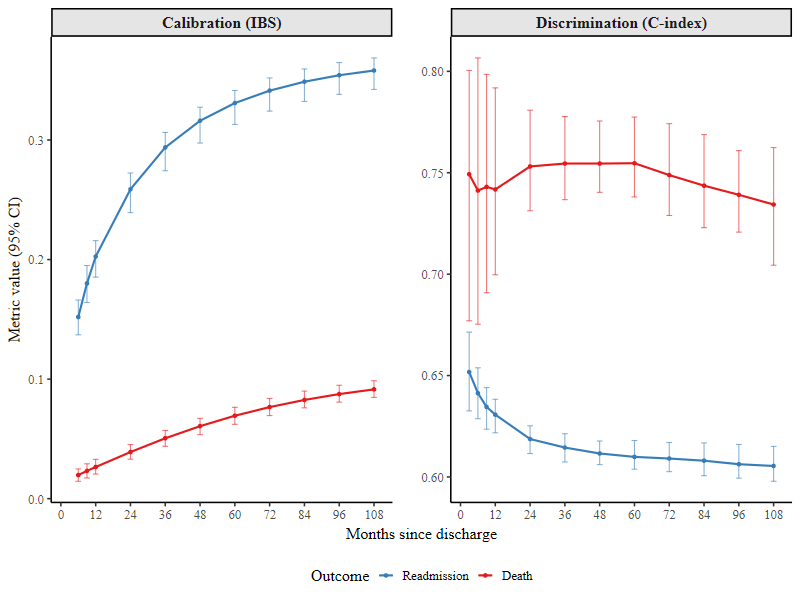

In [69]:
#| label: shap-criteria-int3-dual-cox-python-style-plot-by-time

# Prepare data (ensure proper extraction from results)
time_metrics <- results_shap_xgb_py_upd_int$summary %>%
  dplyr::filter(Time != "Global") %>%
  dplyr::mutate(Time_num = as.numeric(as.character(Time)),
         # Ensure proper ordering of Risk factors
         Risk = factor(Risk, levels = c("Readmission", "Death")))

# Split by metric for separate panels or plots
cindex_data <- time_metrics %>% dplyr::filter(Metric == "Uno's C-Index")
ibs_data <- time_metrics %>% dplyr::filter(Metric == "IBS")

p_faceted_upd_int <- time_metrics %>%
  dplyr::mutate(Metric = ifelse(Metric == "Uno's C-Index", "Discrimination (C-index)", "Calibration (IBS)")) %>%
  ggplot(aes(x = Time_num, y = mean, color = Risk, fill = Risk)) +
  geom_line(linewidth = 1) +
  geom_point(size = 1.5) +
  geom_errorbar(aes(ymin = q025, ymax = q975), width = 2, alpha = 0.6, size = 0.5) +
  facet_wrap(~Metric, scales = "free_y", ncol = 2) +
  scale_color_manual(values = set1_colors) +
  scale_fill_manual(values = set1_colors) +
  scale_x_continuous(breaks = seq(0, 108, by = 12)) +
  labs(x = "Months since discharge",
       y = "Metric value (95% CI)",
       color = "Outcome",
       fill = "Outcome") +
  theme_classic(base_size = 16, base_family= tnr) +
  theme(legend.position = "bottom",
        strip.background = element_rect(fill = "grey90", color = "black"),
        strip.text = element_text(face = "bold", size = 16),
        panel.spacing = unit(2, "lines"))

p_faceted_upd_int



## Functional forms



For readmission model, very short treatment durations (e.g., 0.47 days) have a positive SHAP value (increasing readmission risk). The risk drops to negative values for medium durations (e.g., 2.38 to 3.87 days), and then rises steeply back to positive values for longer durations (e.g., >11 days).

For poverty percentage, theres a threshold / step-function, where lower poverty percentages (8%-9%) are associated with strong negative SHAP values (~ -0.11 to -14). However, once the percentage crosses a threshold (around 13% to 18%) the SHAP impact sharply jumps to strong positive values (~ 0.14).

For admission age, we observe an exponential acceleration (for Death) vs. inverted U-shape (for Readmission). Mortality risk typically follows the Gompertz law (exponential increase with age). Readmission is highly dependent on behavioral factors more prevalent in younger cohorts in this specific dataset.

For evaluation of the therapeutic process, the SHAP values bounce non-linearly across the integer codes. The suggested transformation is one-hot encoding.

In [ ]:
#| label: shap-criteria-func-form-linear-terms-and-scores

# helper: create 3-level score for interaction terms based on main effect and interactor presence
make_3level_score <- function(intermedio, minimo) {
  dplyr::case_when(
    minimo == 1 ~ 2,
    intermedio == 1 ~ 1,
    TRUE ~ 0
  )
}
add_boot_linear_terms <- function(df) {
df <- df %>%
  dplyr::mutate(
    # Constructing linear scores (0 = Ref, 1 = Intermedio, 2 = Minimo) # Categorical variables for readmission
    eva_consumo_score   = eva_consumo_logro_intermedio * 1 + eva_consumo_logro_minimo * 2,
    eva_ocupacion_score = eva_ocupacion_logro_intermedio * 1 + eva_ocupacion_logro_minimo * 2,
    eva_fisica_score    = eva_fisica_logro_intermedio * 1 + eva_fisica_logro_minimo * 2,
    eva_relinterp_score = eva_relinterp_logro_intermedio * 1 + eva_relinterp_logro_minimo * 2,
    # Linear score for Death only, remains dummy for Readmission
    eva_sm_score        = eva_sm_logro_intermedio * 1 + eva_sm_logro_minimo * 2,
    # Constructing others (0 = Ref, 1 = Level 2, 2 = Level 3) # Categorical variables for readmission
    ed_attainment_score = ed_attainment_corr_2_completed_high_school_or_less * 1 + 
                          ed_attainment_corr_3_completed_primary_school_or_less * 2,
    # Categorical variables for readmission                        
    prim_sub_freq_score = prim_sub_freq_rec_2_2_6_days_wk * 1 + prim_sub_freq_rec_3_daily * 2
  )
}
py_corrected_datasets_boot <- lapply(py_corrected_datasets, add_boot_linear_terms)

In [76]:
#| label: shap-criteria-func-form-rcs

# ============================================================
# Functional-form sensitivity models based on actual predictors
# ============================================================

# Requirements:
# 1. Create dit_m_cap36 before fitting readmission models.
# 2. Use fixed knots across imputations/folds, preferably estimated
#    from the development/training data only.
# 3. Do not add variables to the death model that are not already in
#    formula_shap_death_interact unless this is an intentional
#    predictor-set expansion.

# Example data-prep step:

library(dplyr)
library(splines)

add_nonlinear_transf <- function(df) {
  # Capar dit_m en 36
  df <- df %>%
    mutate(
      dit_m_cap36 = pmin(dit_m, 36, na.rm = TRUE),
      
      # Transformaciones spline usando knots fijos
      dit_m_ns1 = ns(dit_m, knots = c(1.1, 3.9, 7.9, 19.3))[,1],
      dit_m_ns2 = ns(dit_m, knots = c(1.1, 3.9, 7.9, 19.3))[,2],
      dit_m_ns3 = ns(dit_m, knots = c(1.1, 3.9, 7.9, 19.3))[,3],
      
      porc_pobr_ns1 = ns(porc_pobr, knots = c(0.053, 0.105, 0.146, 0.261))[,1],
      porc_pobr_ns2 = ns(porc_pobr, knots = c(0.053, 0.105, 0.146, 0.261))[,2],
      porc_pobr_ns3 = ns(porc_pobr, knots = c(0.053, 0.105, 0.146, 0.261))[,3],
      
      age_ns1 = ns(adm_age_rec3,
                   knots = quantile(df$adm_age_rec3,
                                    probs = c(0.05, 0.35, 0.65, 0.95),
                                    na.rm = TRUE))[,1],
      age_ns2 = ns(adm_age_rec3,
                   knots = quantile(df$adm_age_rec3,
                                    probs = c(0.05, 0.35, 0.65, 0.95),
                                    na.rm = TRUE))[,2],
      age_ns3 = ns(adm_age_rec3,
                   knots = quantile(df$adm_age_rec3,
                                    probs = c(0.05, 0.35, 0.65, 0.95),
                                    na.rm = TRUE))[,3]
    )
  
  return(df)
}

  # If you do not want to calculate them manually, use rcs(age, 4).

py_corrected_datasets_boot <- lapply(py_corrected_datasets, add_nonlinear_transf)


In [ ]:
#| label: shap-criteria-func-form-precomputed-ns-readm

# ============================================================
# READMISSION: baseline linear model
# ============================================================
form_readmit_ds_linear <- formula_shap_readmit_interact

# ============================================================
# READMISSION: age natural spline
# ============================================================
form_readmit_ds_age_ns3 <- update(
  formula_shap_readmit_interact,
  . ~ .
    - adm_age_rec3

    + age_ns1 + age_ns2 + age_ns3
)

# ============================================================
# READMISSION: dit_m capped natural spline
# ============================================================
# Replaces raw dit_m with the precomputed spline basis based on dit_m_cap36.
form_readmit_ds_dit_ns3 <- update(
  formula_shap_readmit_interact,
  . ~ .
    - dit_m

    + dit_m_ns1 + dit_m_ns2 + dit_m_ns3
)
# Optional sensitivity: quadratic capped dit_m
form_readmit_ds_dit_quad_sens <- update(
  formula_shap_readmit_interact,
  . ~ .
    - dit_m

    + dit_m_cap36 + I(dit_m_cap36^2)
)
# Optional sensitivity: log capped dit_m
form_readmit_ds_dit_log_sens <- update(
  formula_shap_readmit_interact,
  . ~ .
    - dit_m

    + log1p(dit_m_cap36)
)

# ============================================================
# READMISSION: poverty natural spline
# ============================================================
form_readmit_ds_pobr_ns3 <- update(
  formula_shap_readmit_interact,
  . ~ .
    - porc_pobr

    + porc_pobr_ns1 + porc_pobr_ns2 + porc_pobr_ns3
)

In [ ]:
#| label: shap-criteria-func-form-precomputed-ns-death

# ============================================================
# DEATH: baseline linear model
# ============================================================
form_death_ds_linear <- formula_shap_death_interact

# ============================================================
# DEATH: preferred model
# ============================================================
# Keep linear age as preferred unless the spline sensitivity clearly improves
# AICc/IBS without hurting discrimination.
form_death_ds_preferred <- formula_shap_death_interact

# ============================================================
# DEATH: age natural spline sensitivity
# ============================================================
form_death_ds_age_ns3_sens <- update(
  formula_shap_death_interact,
  . ~ .
    - adm_age_rec3
    - adm_age_rec3:cohabitation_with_couple_children
    - adm_age_rec3:occupation_condition_corr24_unemployed

    + age_ns1 + age_ns2 + age_ns3

    + age_ns1:cohabitation_with_couple_children
    + age_ns2:cohabitation_with_couple_children
    + age_ns3:cohabitation_with_couple_children

    + age_ns1:occupation_condition_corr24_unemployed
    + age_ns2:occupation_condition_corr24_unemployed
    + age_ns3:occupation_condition_corr24_unemployed
)

# Optional simpler sensitivity: quadratic age
form_death_ds_age_quad_sens <- update(
  formula_shap_death_interact,
  . ~ .
    - adm_age_rec3
    - adm_age_rec3:cohabitation_with_couple_children
    - adm_age_rec3:occupation_condition_corr24_unemployed

    + adm_age_rec3 + I(adm_age_rec3^2)

    + adm_age_rec3:cohabitation_with_couple_children
    + I(adm_age_rec3^2):cohabitation_with_couple_children

    + adm_age_rec3:occupation_condition_corr24_unemployed
    + I(adm_age_rec3^2):occupation_condition_corr24_unemployed
)

### Admission age

In [80]:
#| label: shap-criteria-func-form-linear-terms-vs-ns-readmit-test

cat("\nComparing linear age terms vs. polynomial and spline age terms for readmission:\n")
compute_mi_aicc(formula_shap_readmit_interact  , py_corrected_datasets)
compute_mi_aicc(form_readmit_ds_age_ns3  , py_corrected_datasets_boot)



Comparing linear age terms vs. polynomial and spline age terms for readmission:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272559.54
Mean AICc: 272559.63
Correction added (Penalty): 0.085408
Parameters (k): 25 | Effective Sample Size (Events): 15247

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272548.79
Mean AICc: 272548.89
Correction added (Penalty): 0.099349
Parameters (k): 27 | Effective Sample Size (Events): 15247


$mean_aicc
[1] 272548.9

$full_results
       aic correction     aicc  k n_events
1 272549.8  0.0993495 272549.9 27    15247
2 272547.5  0.0993495 272547.6 27    15247
3 272549.5  0.0993495 272549.6 27    15247
4 272548.0  0.0993495 272548.1 27    15247
5 272549.2  0.0993495 272549.3 27    15247


In [82]:
#| label: shap-criteria-func-form-linear-terms-vs-ns-readm-test

gc()

results_shap_py_int_readm_age_ns3 <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_ds_age_ns3,#formula_shap_ds_readmit_interact,
  formula_death = formula_shap_death_interact,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(60, 108)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_xgb_py_upd_int$summary),
  cbind.data.frame(model= "Age spline df=3", results_shap_py_int_readm_age_ns3$summary)
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Readmission") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, readmission model with spline age terms")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, readmission model with spline age terms

|model           |Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:---------------|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear          |Readmission |IBS           |Global | 0.3581284| 0.0078461| 0.3423391| 0.3686435| 25|
|Age spline df=3 |Readmission |IBS           |Global | 0.3882526| 0.0082421| 0.3734313| 0.4009530| 25|
|Linear          |Readmission |Uno's C-Index |Global | 0.6049482| 0.0057035| 0.5955157| 0.6161290| 25|
|Age spline df=3 |Readmission |Uno's C-Index |Global | 0.6050506| 0.0053306| 0.5964908| 0.6156132| 25|


# Final SHAP model



In [23]:
#| label: final-shap-build-splines

gc()

             used   (Mb) gc trigger    (Mb)   max used    (Mb)
Ncells    6421303  343.0   10743420   573.8   10743420   573.8
Vcells 1279867518 9764.7 2083736386 15897.7 1769896875 13503.3

In [24]:
#| label: final-shap-rank-models

#2. Rank models across your imputed dataset list
safe_cox <- function(formula, data) {
  base::tryCatch(
    survival::coxph(
      formula,
      data = data,
      ties = "efron",
      x = TRUE,
      y = TRUE
    ),
    error = function(e) NULL
  )
}
rank_models <- function(forms, data_list) {
  purrr::map_dfr(names(forms), function(nm) {
    fits <- purrr::map(data_list, ~ safe_cox(forms[[nm]], .x))
    aics <- purrr::map_dbl(fits,~ if (base::is.null(.x)) NA_real_ else stats::AIC(.x))
    tibble::tibble(
      model = nm,
      n_fit = base::sum(!base::is.na(aics)),
      median_AIC = stats::median(aics, na.rm = TRUE),
      mean_AIC = base::mean(aics, na.rm = TRUE)
    )
  }) |>
    dplyr::arrange(median_AIC)
}

In [ ]:
#| label: final-shap-plug-to-cv
#4. Plug directly into your existing CV evaluation

readm_forms <- list(
    base_shap_int = formula_shap_readmit_interact,
    spline_main   = formula_readmit_int_spline#,
    #spline_i1     = formula_readmit_int_spline_i1
)
death_forms <- list(
    base_shap_int = formula_shap_death_interact,
    spline_main   = formula_death_int_spline
)

rank_models(readm_forms, py_corrected_datasets_boot)

rank_models(death_forms, py_corrected_datasets_boot)

# A tibble: 2 × 4
  model         n_fit median_AIC mean_AIC
  <chr>         <int>      <dbl>    <dbl>
1 spline_main       5     54159.   54156.
2 base_shap_int     5     54188.   54186.

In [48]:
compare_mi_models_d1(formula_readmit_int_spline, formula_shap_readmit_interact, py_corrected_datasets_boot)
compare_mi_models_d1(formula_death_int_spline, formula_shap_death_interact, py_corrected_datasets_boot)

Fitting the FULL model on 5 imputations...
Fitting the REDUCED model on 5 imputations...
Executing the Wald Test (D1)...

MODEL COMPARISON RESULT (D1 Statistic)
   test statistic df1   df2 dfcom      p.value           riv
 1 ~~ 2   21.7288  10 15213 15215 8.057224e-41 0.00002704545
Fitting the FULL model on 5 imputations...
Fitting the REDUCED model on 5 imputations...
Executing the Wald Test (D1)...

MODEL COMPARISON RESULT (D1 Statistic)
   test statistic df1      df2 dfcom       p.value         riv
 1 ~~ 2  113.0172   9 3009.028  3013 4.982305e-183 0.002491375


In [26]:
#| label: final-shap-int-spline-eval
options(future.globals.maxSize = 12 * 1024^3)

#formula_death_int_spline
results_readmit_int_shap_spl <- evaluate_mi_cv_safe_strata(
    formula = formula_readmit_int_spline, 
    imputed_list = py_corrected_datasets_boot, 
    time_col = "readmit_time_from_disch_m", 
    event_col = "readmit_event",
    k = 5,
    n_repeats = 20
)#
results_death_int_shap_spl <- evaluate_mi_cv_safe_strata(
    formula = formula_death_int_spline, 
    imputed_list = py_corrected_datasets_boot, 
    time_col = "death_time_from_disch_m", 
    event_col = "death_event",
    k = 5,
    n_repeats = 20
)
results_readmit_shap_int_spl_ibs <- cph_evaluate_boot_oob_mi_corrected(
    formula = formula_readmit_int_spline,
    imputed_list = py_corrected_datasets_boot, # List of data.frames
    time_col = "readmit_time_from_disch_m", 
    event_col = "readmit_event",
    tau = 99,                # Evaluate up to 60 months
    B = 500,
    cpus = cpus,
    verbose = TRUE,
    min_strata_events = 1
)
results_death_shap_int_spl_ibs <- cph_evaluate_boot_oob_mi_corrected(
    formula = formula_death_int_spline,
    imputed_list = py_corrected_datasets_boot, # List of data.frames
    time_col = "death_time_from_disch_m", 
    event_col = "death_event",
    tau = 107,                # Evaluate up to 60 months
    B = 500,
    cpus = cpus,
    verbose = TRUE,
    min_strata_events = 1
)
# ====
aicc_readmit_shap_int_spl <- compute_mi_aicc(formula_readmit_int_spline, py_corrected_datasets_boot)
aicc_readmit_shap_int_spl
aicc_death_shap_int_spl <- compute_mi_aicc(formula_death_int_spline, py_corrected_datasets_boot)
aicc_death_shap_int_spl


Starting Evaluation: 5 Imputations x 5 Folds x 20 Repeats = 500 Total Models
------------------------------------------------------------
Global evaluation tau: 99.10 months | C-tau: 94.14 months
Booting up 16 CPU cores using future backend...

FINAL POOLED RESULTS (Cross-Validated + Multiply Imputed)
Global Evaluation Time (tau): 99.10 months
Pooled Uno's C-Index: 0.6096 (repeat-quantile interval 0.6093-0.6100)
Pooled UnoC (survAUC::UnoC): 0.6764 (repeat-quantile interval 0.6436-0.6923)
Pooled IBS: 0.1605 (repeat-quantile interval 0.1604-0.1605)
Pooled IBS (IPCW-train): 0.3480 (repeat-quantile interval 0.3479-0.3482)
RMST-based Uno C-index by horizon:
  t=12 m: C=0.6310 (repeat-quantile interval 0.6306-0.6313, valid repeats=20)
  t=36 m: C=0.6165 (repeat-quantile interval 0.6162-0.6168, valid repeats=20)
  t=60 m: C=0.6126 (repeat-quantile interval 0.6122-0.6129, valid repeats=20)

Total runtime: 869.90 sec (14.50 min)
Starting Evaluation: 5 Imputations x 5 Folds x 20 Repeats = 500 To

There were 50 or more warnings (use warnings() to see the first 50)


Strata variables: plan_type_strata
Categorical vars: plan_type_strata
Bootstrap OOB + MI: B=500, M=5, tau=107.00
Using 8 worker(s)...

FINAL POOLED RESULTS (OOB Bootstrap + MI)
Pooled OOB IBS: 0.0893 (95% CI: 0.0826 - 0.0963)
Valid bootstrap replicates: 500 / 500


There were 16 warnings (use warnings() to see them)



AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272443.79
Mean AICc: 272443.93
Correction added (Penalty): 0.138820
Parameters (k): 32 | Effective Sample Size (Events): 15247

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  54156.44
Mean AICc: 54156.90
Correction added (Penalty): 0.466135
Parameters (k): 26 | Effective Sample Size (Events): 3039


$mean_aicc
[1] 54156.9

$full_results
       aic correction     aicc  k n_events
1 54144.71  0.4661355 54145.17 26     3039
2 54166.42  0.4661355 54166.88 26     3039
3 54161.88  0.4661355 54162.34 26     3039
4 54158.60  0.4661355 54159.06 26     3039
5 54150.58  0.4661355 54151.05 26     3039


In [59]:
cal_readmit_shap_int_spl_ici <- calibrate_cph_grouped(
    formula = formula_readmit_int_spline,
    data = py_corrected_datasets_boot,
    times = c(12, 36, 60),
    validation = "cv",
    folds = 5,
    n_repeats = 20,
    compute_ici = TRUE,
    ici_times = 60,
    make_plots = TRUE
)
print(cal_readmit_shap_int_spl_ici)

Detected time variable: readmit_time_from_disch_m
Detected event variable: readmit_event
Using 5 imputed dataset(s).
Validation: cv
Repetitions: 20 | same fold split across imputations within each repetition.
ICI: enabled at horizons 60.
Predicting repetition 1/20... done
Predicting repetition 2/20... done
Predicting repetition 3/20... done
Predicting repetition 4/20... done
Predicting repetition 5/20... done
Predicting repetition 6/20... done
Predicting repetition 7/20... done
Predicting repetition 8/20... done
Predicting repetition 9/20... done
Predicting repetition 10/20... done
Predicting repetition 11/20... done
Predicting repetition 12/20... done
Predicting repetition 13/20... done
Predicting repetition 14/20... done
Predicting repetition 15/20... done
Predicting repetition 16/20... done
Predicting repetition 17/20... done
Predicting repetition 18/20... done
Predicting repetition 19/20... done
Predicting repetition 20/20... done
Calibrating repetition 1/20... done
Calibrating rep

Using 5 imputed dataset(s).
Validation: cv
Repetitions: 20 | same fold split across imputations within each repetition.
ICI: enabled at horizons 60.
Predicting repetition 1/20... done
Predicting repetition 2/20... done
Predicting repetition 3/20... done
Predicting repetition 4/20... done
Predicting repetition 5/20... done
Predicting repetition 6/20... done
Predicting repetition 7/20... done
Predicting repetition 8/20... done
Predicting repetition 9/20... done
Predicting repetition 10/20... done
Predicting repetition 11/20... done
Predicting repetition 12/20... done
Predicting repetition 13/20... done
Predicting repetition 14/20... done
Predicting repetition 15/20... done
Predicting repetition 16/20... done
Predicting repetition 17/20... done
Predicting repetition 18/20... done
Predicting repetition 19/20... done
Predicting repetition 20/20... done
Calibrating repetition 1/20... done
Calibrating repetition 2/20... done
Calibrating repetition 3/20... done
Calibrating repetition 4/20... d

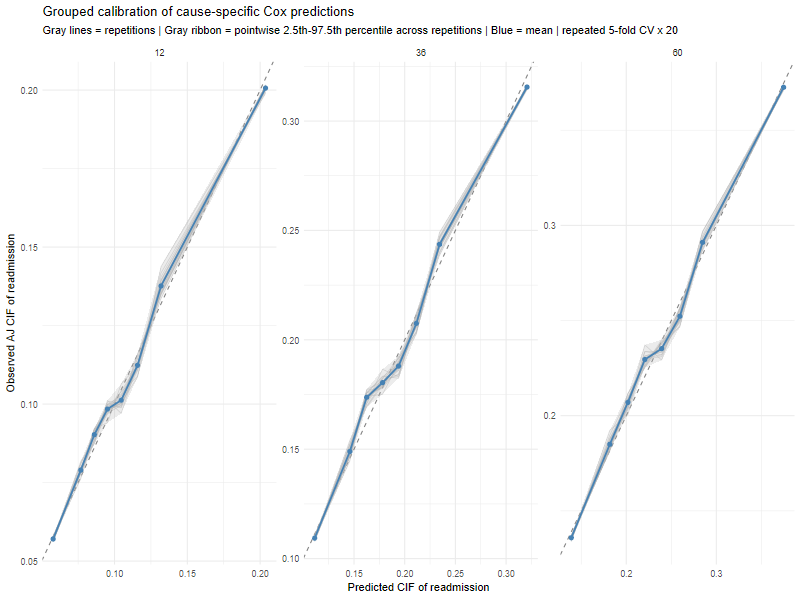

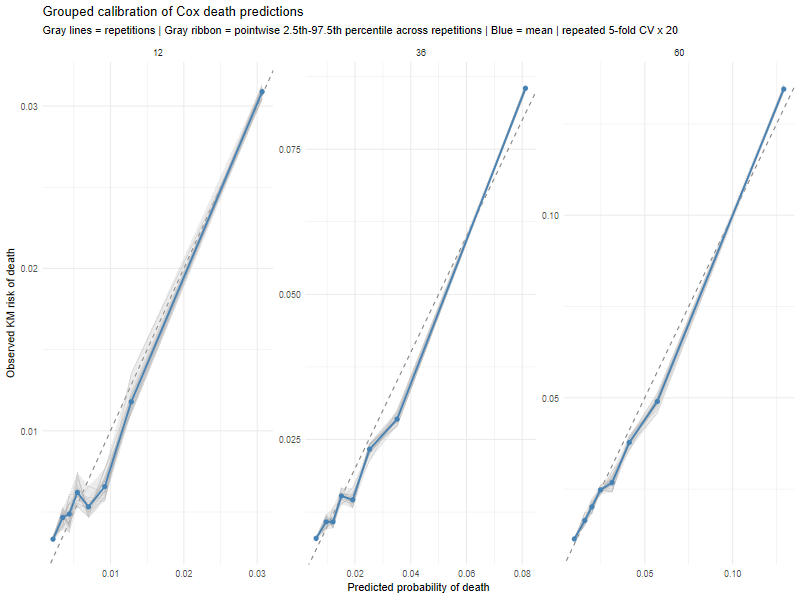

In [ ]:
#| label: calib-shap
gc()
cal_readmit_aj_rcv <- calibrate_cscox_aj_grouped(
    formula_readmit = formula_readmit_int_spline,
    formula_death = formula_death_int_spline,
    data = py_corrected_datasets_boot,
    times = c(12, 36, 60),
    n_imputations = 5,
    validation = "cv",
    folds = 5,
    n_repeats = 20,
    compute_ici = TRUE,
    ici_times = 60,
    make_plots = TRUE,
    g = 10,
    min_bin_n = 20,
    seed = 2125
)
print(cal_readmit_aj_rcv)
plot(cal_readmit_aj_rcv)


cal_death_ici <- calibrate_cph_grouped(
    formula = formula_death_int_spline,
    data = py_corrected_datasets_boot,
    times = c(12, 36, 60),
    validation = "cv",
    folds = 5,
    n_repeats = 20,
    compute_ici = TRUE,
    ici_times = 60,
    make_plots = TRUE
)
print(cal_death_ici)
plot(cal_death_ici)

# Methods
# We fitted cause-specific Cox models for readmission and death, and combined them to estimate the predicted cumulative incidence of readmission at 12, 36, and 60 months. Calibration was assessed by comparing grouped predicted risks against observed Aalen–Johansen estimates of readmission, thereby accounting for the competing risk of death. To reduce optimism, calibration was evaluated using 5-fold cross-validation across imputations.
# 
# Results
# The cause-specific Cox models showed excellent calibration for readmission risk at all evaluated horizons. Cross-validated expected-to-observed ratios were 0.99 at 12 months, 0.99 at 36 months, and 0.98 at 60 months, indicating minimal miscalibration in the large. Grouped expected calibration error was also very low across horizons (12 months: 0.0029; 36 months: 0.0041; 60 months: 0.0040).
# One thing: in your message, the printed output corresponds to one fitted object, but the second call with formula_readmit_int_spline2 and formula_death_int_spline does not show its printed result yet. So I can interpret the first object with certainty; for the second one, I’d need the printed summary too.


In [ ]:
# Source the script
source(paste0(project_root,"/cons/_alt_scripts/evaluate_dual_cox_python_style_boot.R"))

# Define your model formula
formula_death <- Surv(death_time_from_disch_m, death_event) ~ 
  age + sex + plan_type_corr + comorbidity_score + strata(plan_type_strata)

results_boot <- evaluate_dual_cox_python_style(
  formula_readmit = formula_readmit_int_spline,
  formula_death = formula_death_int_spline,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3, 6, 9, 12, 24, 36, 48, 60, 72, 84, 96, 108)
)


Starting dual Cox evaluation: 5 imputations x 10 folds = 50 fold pairs
Imp 1/5: ..........
Imp 2/5: ..........
Imp 3/5: ..........
Imp 4/5: ..



# Session info



In [34]:
#| label: session-info
#| echo: true
#| error: true
#| message: true
#| paged.print: true
message(paste0("R library: ", Sys.getenv("R_LIBS_USER")))
message(paste0("Date: ",withr::with_locale(new = c('LC_TIME' = 'C'), code =Sys.time())))
message(paste0("Editor context: ", path))
cat("quarto version: "); quarto::quarto_version()
sesion_info <- devtools::session_info()

library(htmltools)
tabla <- dplyr::select(
  tibble::as_tibble(sesion_info$packages),
  c(package, loadedversion, source)
) |> 
  DT::datatable(
    filter = 'top',
    colnames = c('Row number' = 1, 'Package' = 2, 'Version' = 3),
    caption = htmltools::tags$caption(
      style = 'caption-side: top; text-align: left;',
      '', htmltools::em('R packages')
    ),
    options = list(
      pageLength = 10,
      initComplete = htmlwidgets::JS(
        "function(settings, json) {",
        "$(this.api().tables().body()).css({
            'font-family': 'Helvetica Neue',
            'font-size': '70%', 
            'white-space': 'nowrap',
            'line-height': '0.75em'
        });",
        "}"
      )
    )
  )

# Guardar el HTML
htmlwidgets::saveWidget(tabla, "tabla_packages.html", selfcontained = TRUE)

# Leer y mostrar el HTML (copia esto)
#cat(readLines("tabla_packages.html"), sep = "\n")

R library: G:/My Drive/Alvacast/SISTRAT 2023/renv/library/windows/R-4.4/x86_64-w64-mingw32
Date: 2026-03-27 08:20:26.463439
Editor context: G:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/251001_c1_1025_df_prev1y.rds
quarto version: 

Warning message:
In system2("quarto", "-V", stdout = TRUE, env = paste0("TMPDIR=",  :
  running command '"quarto" TMPDIR=C:/Users/andre/AppData/Local/Temp/RtmpYDfCbF/file8fdc570b54bc -V' had status 1



Save



In [29]:
#| label: save
#| echo: true
#| error: true
#| warning: true
#| message: true
#| paged.print: true
#| results: "hold"
#| eval: true
wdpath<-
paste0(gsub("/cons","",gsub("cons","",paste0(getwd(),"/cons"))))
envpath<- if(regmatches(wdpath, regexpr("[A-Za-z]+", wdpath))=="G"){"G:/Mi unidad/Alvacast/SISTRAT 2023/"}else{"E:/Mi unidad/Alvacast/SISTRAT 2023/"}
paste0(getwd(),"/cons")
file.path(paste0(wdpath,"data/20241015_out"))
file.path(paste0(envpath,"data/20241015_out"))
# Save
rdata_path <- file.path(wdpath, "data/20241015_out", paste0("pred22_ndp_", format(Sys.time(), "%Y_%m_%d"), ".Rdata"))
save.image(rdata_path)
cat("Saved in:",
    rdata_path)
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
if (Sys.getenv("RSTUDIO_SESSION_TYPE") == "server" || file.exists("/.dockerenv")) {
  password <- Sys.getenv("PASSWORD_SECRET")
} else {
  if (interactive()) {
    utils::savehistory(tempfile())
    Sys.setenv(PASSWORD_SECRET = readLines(paste0(wdpath, "secret.txt"), warn = FALSE))
    utils::loadhistory()
  }
  Sys.setenv(PASSWORD_SECRET = readLines(paste0(wdpath, "secret.txt"), warn = FALSE))
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
save.image(paste0(rdata_path,".enc"))
# Encriptar el archivo en el mismo lugar
httr2::secret_encrypt_file(path = paste0(rdata_path,".enc"), key = "PASSWORD_SECRET")
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
cat("Copy renv lock into cons folder\n")
if (Sys.getenv("RSTUDIO_SESSION_TYPE") == "server" || file.exists("/.dockerenv")) {
  message("Running on RStudio Server or inside Docker. Folder copy skipped.")
} else {
    
  source_folder <- 
  destination_folder <- paste0(wdpath,"cons/renv")
  
  # Copy the folder recursively
    file.copy(paste0(wdpath,"renv.lock"), paste0(wdpath,"cons/renv.lock"), overwrite = TRUE)
  
  message("Renv lock copy performed.")
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
time_after_dedup2<-Sys.time()

Saved in: g:/My Drive/Alvacast/SISTRAT 2023///data/20241015_out/pred22_ndp_2026_03_27.RdataCopy renv lock into cons folder
Renv lock copy performed.
